In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
import logging
import os

# --------------------------------------------------
# MySQL Configuration
# --------------------------------------------------
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DATABASE = "telecom_analytics"
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"   # <-- put your real password here

MYSQL_URL = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

# --------------------------------------------------
# Logging
# --------------------------------------------------
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(
            "logs/ml3_notebook.log",
            encoding="utf-8"
        ),
        logging.StreamHandler()
    ]
)

logging.info("Creating MySQL SQLAlchemy engine...")

engine = create_engine(
    MYSQL_URL,
    pool_pre_ping=True
)

# --------------------------------------------------
# Connection Test
# --------------------------------------------------
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        value = result.scalar()

    logging.info("MySQL connection successful.")
    logging.info("Test query result: %s", value)

except Exception as e:
    logging.exception("MySQL connection failed.")
    raise

2026-09-07 15:09:44,157 | INFO | Creating MySQL SQLAlchemy engine...
2026-09-07 15:09:44,255 | INFO | MySQL connection successful.
2026-09-07 15:09:44,257 | INFO | Test query result: 1


In [2]:
tables = pd.read_sql(
    "SHOW TABLES",
    engine
)

logging.info(
    "Retrieved %d tables from telecom_analytics database.",
    len(tables)
)

print(tables)

2026-09-07 15:09:44,287 | INFO | Retrieved 5 tables from telecom_analytics database.


  Tables_in_telecom_analytics
0             activity_alerts
1                    dim_grid
2                    dim_time
3       fact_network_activity
4       network_feature_table


In [3]:
# ============================================================
# CELL 3 — Load ML2 Feature Table from MySQL
# ============================================================

import pandas as pd
import logging

logging.info("Loading network_feature_table from MySQL...")

feature_query = """
SELECT
    grid_id,
    feature_timestamp,
    avg_activity,
    activity_growth,
    active_hours,
    peak_ratio,
    variability,
    internet_share
FROM network_feature_table
ORDER BY feature_timestamp, grid_id
"""

feature_df = pd.read_sql(
    feature_query,
    engine
)

logging.info(
    "Loaded network_feature_table | rows=%d | columns=%d",
    len(feature_df),
    len(feature_df.columns)
)

print("Shape:", feature_df.shape)
print("\nColumns:")
print(feature_df.columns.tolist())

print("\nFirst 5 rows:")
display(feature_df.head())

print("\nData types:")
print(feature_df.dtypes)

2026-09-07 15:09:44,305 | INFO | Loading network_feature_table from MySQL...
2026-09-07 15:10:03,293 | INFO | Loaded network_feature_table | rows=1209884 | columns=8


Shape: (1209884, 8)

Columns:
['grid_id', 'feature_timestamp', 'avg_activity', 'activity_growth', 'active_hours', 'peak_ratio', 'variability', 'internet_share']

First 5 rows:


,grid_id,feature_timestamp,avg_activity,activity_growth,active_hours,peak_ratio,variability,internet_share
0,1,2013-11-02 23:00:00,72.808913,0.015350,24,1.679848,27.005538,0.867363
1,2,2013-11-02 23:00:00,73.255771,0.016225,24,1.677304,27.247901,0.866102
2,3,2013-11-02 23:00:00,73.731308,0.017148,24,1.674622,27.506530,0.864779
3,4,2013-11-02 23:00:00,71.515008,0.012760,24,1.687412,26.307629,0.871097
4,5,2013-11-02 23:00:00,65.406742,0.014276,24,1.659236,24.169419,0.868378



Data types:
grid_id                       int64
feature_timestamp    datetime64[us]
avg_activity                float64
activity_growth             float64
active_hours                  int64
peak_ratio                  float64
variability                 float64
internet_share              float64
dtype: object


In [4]:
# ============================================================
# CELL 4 — Validate ML2 Feature Table
# ============================================================

logging.info("Validating network_feature_table...")

# Convert timestamp explicitly
feature_df["feature_timestamp"] = pd.to_datetime(
    feature_df["feature_timestamp"]
)

# Basic information
print("Rows:", len(feature_df))
print("Unique grids:", feature_df["grid_id"].nunique())
print(
    "Feature timestamp range:",
    feature_df["feature_timestamp"].min(),
    "to",
    feature_df["feature_timestamp"].max()
)

# Null check
null_counts = feature_df.isnull().sum()

print("\nNull values:")
print(null_counts)

# Duplicate check
duplicate_count = feature_df.duplicated(
    subset=["grid_id", "feature_timestamp"]
).sum()

print("\nDuplicate grid/timestamp rows:", duplicate_count)

# Numeric summary
print("\nFeature summary:")
display(
    feature_df[
        [
            "avg_activity",
            "activity_growth",
            "active_hours",
            "peak_ratio",
            "variability",
            "internet_share"
        ]
    ].describe()
)

logging.info(
    "Feature validation complete | duplicates=%d | total_nulls=%d",
    duplicate_count,
    int(null_counts.sum())
)

2026-09-07 15:10:03,360 | INFO | Validating network_feature_table...


Rows: 1209884
Unique grids: 10000
Feature timestamp range: 2013-11-02 23:00:00 to 2013-11-07 23:00:00

Null values:
grid_id              0
feature_timestamp    0
avg_activity         0
activity_growth      0
active_hours         0
peak_ratio           0
variability          0
internet_share       0
dtype: int64

Duplicate grid/timestamp rows: 0

Feature summary:


,avg_activity,activity_growth,active_hours,peak_ratio,variability,internet_share
count,1.209884e+06,1.209884e+06,1209884.0,1.209884e+06,1.209884e+06,1.209884e+06
mean,5.090917e+02,7.752632e-02,24.0,1.679421e+00,2.180846e+02,8.291788e-01
std,8.406708e+02,2.506443e-01,0.0,3.237045e-01,4.595951e+02,5.974602e-02
min,2.062433e+00,-8.706159e-01,24.0,1.116764e+00,5.578587e-01,2.621592e-02
25%,9.938309e+01,-2.223358e-02,24.0,1.476448e+00,3.802371e+01,8.040609e-01
50%,2.480499e+02,2.502869e-02,24.0,1.593260e+00,9.483530e+01,8.374062e-01
75%,5.300162e+02,9.840463e-02,24.0,1.777615e+00,2.096069e+02,8.678921e-01
max,1.451485e+04,1.043025e+01,24.0,9.766951e+00,1.445194e+04,9.743463e-01


2026-09-07 15:10:03,758 | INFO | Feature validation complete | duplicates=0 | total_nulls=0


In [5]:
# ============================================================
# CELL 5 — Load Required Activity Data
# ============================================================

logging.info("Loading activity data from fact_network_activity...")

activity_query = """
SELECT
    dg.grid_id,
    dt.timestamp AS timestamp,
    f.total_activity
FROM fact_network_activity f
JOIN dim_grid dg
    ON f.grid_key = dg.grid_key
JOIN dim_time dt
    ON f.time_key = dt.time_key
ORDER BY dt.timestamp, dg.grid_id
"""

activity_df = pd.read_sql(
    activity_query,
    engine
)

logging.info(
    "Loaded activity data | rows=%d | columns=%d",
    len(activity_df),
    len(activity_df.columns)
)

activity_df["timestamp"] = pd.to_datetime(
    activity_df["timestamp"]
)

print("Shape:", activity_df.shape)
print("\nColumns:")
print(activity_df.columns.tolist())

print("\nFirst 5 rows:")
display(activity_df.head())

print("\nTimestamp range:")
print(
    activity_df["timestamp"].min(),
    "to",
    activity_df["timestamp"].max()
)

print("\nUnique grids:", activity_df["grid_id"].nunique())

2026-09-07 15:10:03,771 | INFO | Loading activity data from fact_network_activity...
2026-09-07 15:12:28,235 | INFO | Loaded activity data | rows=1679994 | columns=3


Shape: (1679994, 3)

Columns:
['grid_id', 'timestamp', 'total_activity']

First 5 rows:


,grid_id,timestamp,total_activity
0,1,2013-11-01,62.0092
1,2,2013-11-01,62.1346
2,3,2013-11-01,62.2679
3,4,2013-11-01,61.6463
4,5,2013-11-01,55.9711



Timestamp range:
2013-11-01 00:00:00 to 2013-11-07 23:00:00

Unique grids: 10000


In [6]:
# ============================================================
# CELL 6 — Validate Activity Data
# ============================================================

logging.info("Validating activity data...")

null_counts = activity_df.isnull().sum()

duplicate_count = activity_df.duplicated(
    subset=["grid_id", "timestamp"]
).sum()

print("Rows:", len(activity_df))
print("Unique grids:", activity_df["grid_id"].nunique())
print("Unique timestamps:", activity_df["timestamp"].nunique())

print("\nNull values:")
print(null_counts)

print(
    "\nDuplicate grid/timestamp rows:",
    duplicate_count
)

print("\nActivity statistics:")
display(
    activity_df["total_activity"].describe()
)

logging.info(
    "Activity validation complete | duplicates=%d | total_nulls=%d",
    duplicate_count,
    int(null_counts.sum())
)

2026-09-07 15:12:28,310 | INFO | Validating activity data...


Rows: 1679994
Unique grids: 10000
Unique timestamps: 168

Null values:
grid_id           0
timestamp         0
total_activity    0
dtype: int64

Duplicate grid/timestamp rows: 0

Activity statistics:


count    1.679994e+06
mean     4.902707e+02
std      9.362976e+02
min      3.183000e-01
25%      8.246445e+01
50%      2.115289e+02
75%      5.017953e+02
max      3.798178e+04
Name: total_activity, dtype: float64

2026-09-07 15:12:28,483 | INFO | Activity validation complete | duplicates=0 | total_nulls=0


In [7]:
# ============================================================
# CELL 7 — Calculate Trailing 24-Hour Median
# ============================================================

logging.info(
    "Creating trailing 24-hour median baseline for ML3 target..."
)

# Work on a sorted copy
activity_df = activity_df.sort_values(
    ["grid_id", "timestamp"]
).reset_index(drop=True)

# Convert timestamp to datetime if not already
activity_df["timestamp"] = pd.to_datetime(
    activity_df["timestamp"]
)

# ------------------------------------------------------------
# Calculate rolling median
# Window = current hour + previous 23 hours
# ------------------------------------------------------------

activity_df["trailing_median_24h"] = (
    activity_df
    .groupby("grid_id")["total_activity"]
    .rolling(
        window=24,
        min_periods=24
    )
    .median()
    .reset_index(level=0, drop=True)
)

logging.info(
    "Trailing median calculation completed."
)

print("Rows:", len(activity_df))

print("\nTrailing median null count:")
print(
    activity_df["trailing_median_24h"].isna().sum()
)

print("\nTrailing median statistics:")
display(
    activity_df["trailing_median_24h"].describe()
)

print("\nSample:")
display(
    activity_df[
        [
            "grid_id",
            "timestamp",
            "total_activity",
            "trailing_median_24h"
        ]
    ].head(30)
)

2026-09-07 15:12:28,498 | INFO | Creating trailing 24-hour median baseline for ML3 target...
2026-09-07 15:12:29,577 | INFO | Trailing median calculation completed.


Rows: 1679994

Trailing median null count:
230000

Trailing median statistics:


count    1.449994e+06
mean     5.103849e+02
std      8.120814e+02
min      2.222800e+00
25%      9.978050e+01
50%      2.513306e+02
75%      5.376125e+02
max      1.115455e+04
Name: trailing_median_24h, dtype: float64


Sample:


,grid_id,timestamp,total_activity,trailing_median_24h
0,1,2013-11-01 00:00:00,62.0092,NaN
1,1,2013-11-01 01:00:00,46.3654,NaN
2,1,2013-11-01 02:00:00,42.0870,NaN
3,1,2013-11-01 03:00:00,35.0978,NaN
4,1,2013-11-01 04:00:00,32.2741,NaN
5,1,2013-11-01 05:00:00,35.4160,NaN
6,1,2013-11-01 06:00:00,36.1216,NaN
7,1,2013-11-01 07:00:00,44.7950,NaN
8,1,2013-11-01 08:00:00,67.4200,NaN
9,1,2013-11-01 09:00:00,83.7437,NaN


In [8]:
# ============================================================
# CELL 8 — Validate Hourly Continuity
# ============================================================

logging.info(
    "Checking hourly timestamp continuity by grid..."
)

# Difference between consecutive timestamps within each grid
activity_df["hour_gap"] = (
    activity_df
    .groupby("grid_id")["timestamp"]
    .diff()
)

# Find gaps that are not exactly one hour
gap_rows = activity_df[
    activity_df["hour_gap"].notna()
    & (activity_df["hour_gap"] != pd.Timedelta(hours=1))
].copy()

print(
    "Number of non-1-hour gaps:",
    len(gap_rows)
)

if len(gap_rows) > 0:
    print("\nDetected gaps:")
    display(
        gap_rows[
            [
                "grid_id",
                "timestamp",
                "hour_gap"
            ]
        ].head(20)
    )

logging.info(
    "Continuity check complete | non_1h_gaps=%d",
    len(gap_rows)
)

2026-09-07 15:12:29,668 | INFO | Checking hourly timestamp continuity by grid...


Number of non-1-hour gaps: 5

Detected gaps:


,grid_id,timestamp,hour_gap
880036,5239,2013-11-03 05:00:00,0 days 02:00:00
880059,5239,2013-11-04 05:00:00,0 days 02:00:00
880080,5239,2013-11-05 03:00:00,0 days 02:00:00
880105,5239,2013-11-06 06:00:00,0 days 03:00:00
880126,5239,2013-11-07 04:00:00,0 days 02:00:00


2026-09-07 15:12:29,761 | INFO | Continuity check complete | non_1h_gaps=5


In [9]:
# ============================================================
# CELL 9 — Correct 24-Hour Historical Median
# ============================================================

logging.info(
    "Creating corrected 24-hour historical median baseline..."
)

# ------------------------------------------------------------
# We need exactly:
#
# t-23, t-22, ..., t-1, t
#
# = 24 hourly observations
#
# ------------------------------------------------------------

activity_df = activity_df.sort_values(
    ["grid_id", "timestamp"]
).reset_index(drop=True)

# Calculate the timestamp of the observation 23 rows before
activity_df["window_start_timestamp"] = (
    activity_df
    .groupby("grid_id")["timestamp"]
    .shift(23)
)

# Calculate number of observations in the 24-row window
activity_df["historical_count_24h"] = (
    activity_df
    .groupby("grid_id")["total_activity"]
    .rolling(
        window=24,
        min_periods=24
    )
    .count()
    .reset_index(level=0, drop=True)
)

# ------------------------------------------------------------
# Verify that the 24 rows actually span exactly 23 hours.
#
# If they do:
#
# window_start = t - 23 hours
#
# If a historical hour is missing, the 23-row difference
# becomes greater than 23 hours.
# ------------------------------------------------------------

activity_df["window_duration"] = (
    activity_df["timestamp"]
    - activity_df["window_start_timestamp"]
)

activity_df["complete_24h_window"] = (
    (activity_df["historical_count_24h"] == 24)
    &
    (
        activity_df["window_duration"]
        == pd.Timedelta(hours=23)
    )
)

# ------------------------------------------------------------
# Calculate rolling median.
# ------------------------------------------------------------

activity_df["trailing_median_24h"] = (
    activity_df
    .groupby("grid_id")["total_activity"]
    .rolling(
        window=24,
        min_periods=24
    )
    .median()
    .reset_index(level=0, drop=True)
)

# Remove median where the 24 observations are not
# actually consecutive hourly observations.

activity_df.loc[
    ~activity_df["complete_24h_window"],
    "trailing_median_24h"
] = pd.NA

logging.info(
    "Corrected trailing median calculation completed."
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

complete_count = activity_df[
    "complete_24h_window"
].sum()

incomplete_count = len(activity_df) - complete_count

print("Total activity rows:", len(activity_df))
print("Complete 24-hour windows:", complete_count)
print("Incomplete 24-hour windows:", incomplete_count)

print("\nHistorical count distribution:")
print(
    activity_df["historical_count_24h"]
    .value_counts()
    .sort_index()
    .head(30)
)

print("\nComplete window status:")
print(
    activity_df["complete_24h_window"]
    .value_counts()
)

logging.info(
    "24-hour window validation | complete=%d | incomplete=%d",
    complete_count,
    incomplete_count
)

2026-09-07 15:12:29,782 | INFO | Creating corrected 24-hour historical median baseline...
2026-09-07 15:12:31,033 | INFO | Corrected trailing median calculation completed.
2026-09-07 15:12:31,107 | INFO | 24-hour window validation | complete=1449886 | incomplete=230108


Total activity rows: 1679994
Complete 24-hour windows: 1449886
Incomplete 24-hour windows: 230108

Historical count distribution:
historical_count_24h
24.0    1449994
Name: count, dtype: int64

Complete window status:
complete_24h_window
True     1449886
False     230108
Name: count, dtype: int64


In [10]:
# ============================================================
# CELL 10 — Create Next-Hour Activity (t+1)
# ============================================================

logging.info(
    "Creating next-hour activity target (t+1)..."
)

# Next timestamp within each grid
activity_df["target_timestamp"] = (
    activity_df
    .groupby("grid_id")["timestamp"]
    .shift(-1)
)

# Next-hour activity within each grid
activity_df["target_activity"] = (
    activity_df
    .groupby("grid_id")["total_activity"]
    .shift(-1)
)

# ------------------------------------------------------------
# Verify that the shifted observation is actually t+1 hour.
# A missing hour must NOT be treated as the next hour.
# ------------------------------------------------------------

activity_df["target_time_gap"] = (
    activity_df["target_timestamp"]
    - activity_df["timestamp"]
)

activity_df["valid_next_hour"] = (
    activity_df["target_time_gap"]
    == pd.Timedelta(hours=1)
)

logging.info(
    "Next-hour activity calculation completed."
)

print(
    "Rows with valid t+1 target:",
    activity_df["valid_next_hour"].sum()
)

print(
    "Rows without valid t+1 target:",
    (~activity_df["valid_next_hour"]).sum()
)

print("\nTarget time-gap distribution:")
print(
    activity_df["target_time_gap"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nSample:")
display(
    activity_df[
        [
            "grid_id",
            "timestamp",
            "total_activity",
            "target_timestamp",
            "target_activity",
            "target_time_gap",
            "valid_next_hour"
        ]
    ].head(30)
)

2026-09-07 15:12:31,122 | INFO | Creating next-hour activity target (t+1)...
2026-09-07 15:12:31,230 | INFO | Next-hour activity calculation completed.


Rows with valid t+1 target: 1669989
Rows without valid t+1 target: 10005

Target time-gap distribution:
target_time_gap
0 days 01:00:00    1669989
NaT                  10000
0 days 02:00:00          4
0 days 03:00:00          1
Name: count, dtype: int64

Sample:


,grid_id,timestamp,total_activity,target_timestamp,target_activity,target_time_gap,valid_next_hour
0,1,2013-11-01 00:00:00,62.0092,2013-11-01 01:00:00,46.3654,0 days 01:00:00,True
1,1,2013-11-01 01:00:00,46.3654,2013-11-01 02:00:00,42.0870,0 days 01:00:00,True
2,1,2013-11-01 02:00:00,42.0870,2013-11-01 03:00:00,35.0978,0 days 01:00:00,True
3,1,2013-11-01 03:00:00,35.0978,2013-11-01 04:00:00,32.2741,0 days 01:00:00,True
4,1,2013-11-01 04:00:00,32.2741,2013-11-01 05:00:00,35.4160,0 days 01:00:00,True
5,1,2013-11-01 05:00:00,35.4160,2013-11-01 06:00:00,36.1216,0 days 01:00:00,True
6,1,2013-11-01 06:00:00,36.1216,2013-11-01 07:00:00,44.7950,0 days 01:00:00,True
7,1,2013-11-01 07:00:00,44.7950,2013-11-01 08:00:00,67.4200,0 days 01:00:00,True
8,1,2013-11-01 08:00:00,67.4200,2013-11-01 09:00:00,83.7437,0 days 01:00:00,True
9,1,2013-11-01 09:00:00,83.7437,2013-11-01 10:00:00,100.7637,0 days 01:00:00,True


In [11]:
# ============================================================
# CELL 11 — Validate t+1 Completeness
# ============================================================

logging.info(
    "Validating next-hour target completeness..."
)

# Rows where a next row exists but it is NOT exactly one hour later
invalid_next_hour = activity_df[
    activity_df["target_timestamp"].notna()
    & (~activity_df["valid_next_hour"])
].copy()

print(
    "Rows with non-consecutive next timestamp:",
    len(invalid_next_hour)
)

if len(invalid_next_hour) > 0:
    print("\nExamples:")
    display(
        invalid_next_hour[
            [
                "grid_id",
                "timestamp",
                "target_timestamp",
                "target_time_gap"
            ]
        ].head(20)
    )

# Rows with no next observation at all
no_next_observation = activity_df[
    activity_df["target_timestamp"].isna()
]

print(
    "\nRows with no next observation:",
    len(no_next_observation)
)

logging.info(
    "t+1 validation complete | invalid_gap=%d | no_next=%d",
    len(invalid_next_hour),
    len(no_next_observation)
)

2026-09-07 15:12:31,261 | INFO | Validating next-hour target completeness...


Rows with non-consecutive next timestamp: 5

Examples:


,grid_id,timestamp,target_timestamp,target_time_gap
880035,5239,2013-11-03 03:00:00,2013-11-03 05:00:00,0 days 02:00:00
880058,5239,2013-11-04 03:00:00,2013-11-04 05:00:00,0 days 02:00:00
880079,5239,2013-11-05 01:00:00,2013-11-05 03:00:00,0 days 02:00:00
880104,5239,2013-11-06 03:00:00,2013-11-06 06:00:00,0 days 03:00:00
880125,5239,2013-11-07 02:00:00,2013-11-07 04:00:00,0 days 02:00:00


2026-09-07 15:12:31,280 | INFO | t+1 validation complete | invalid_gap=5 | no_next=10000



Rows with no next observation: 10000


In [12]:
# ============================================================
# CELL 12 — Create Locked ML3 HIGH_ACTIVITY Target
# ============================================================

logging.info(
    "Creating locked ML3 HIGH_ACTIVITY target..."
)

# ------------------------------------------------------------
# A row can become a labeled ML example only when:
#
# 1. Historical 24-hour window is complete
# 2. Next-hour target exists
# 3. Next-hour timestamp is exactly t+1
# ------------------------------------------------------------

label_eligible = (
    activity_df["complete_24h_window"]
    &
    activity_df["valid_next_hour"]
    &
    activity_df["trailing_median_24h"].notna()
    &
    activity_df["target_activity"].notna()
)

logging.info(
    "Label-eligible rows: %d",
    label_eligible.sum()
)

# ------------------------------------------------------------
# Create label
#
# HIGH_ACTIVITY(t+1) = 1 when:
#
# Activity(t+1) >
# 1.5 × Median(Activity(t-23:t))
# ------------------------------------------------------------

activity_df["high_activity"] = pd.NA

activity_df.loc[
    label_eligible,
    "high_activity"
] = (
    activity_df.loc[
        label_eligible,
        "target_activity"
    ]
    >
    1.5
    *
    activity_df.loc[
        label_eligible,
        "trailing_median_24h"
    ]
).astype(int)

logging.info(
    "HIGH_ACTIVITY target created."
)

print(
    "Total rows:",
    len(activity_df)
)

print(
    "Label-eligible rows:",
    label_eligible.sum()
)

print(
    "Rows without label:",
    activity_df["high_activity"].isna().sum()
)

print("\nLabel distribution:")
print(
    activity_df["high_activity"].value_counts(
        dropna=False
    )
)

2026-09-07 15:12:31,294 | INFO | Creating locked ML3 HIGH_ACTIVITY target...
2026-09-07 15:12:31,307 | INFO | Label-eligible rows: 1439885
2026-09-07 15:12:31,378 | INFO | HIGH_ACTIVITY target created.


Total rows: 1679994
Label-eligible rows: 1439885
Rows without label: 240109

Label distribution:
high_activity
0       1303819
<NA>     240109
1        136066
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 13 — Validate ML3 Target Distribution
# ============================================================

logging.info(
    "Validating HIGH_ACTIVITY target distribution..."
)

labeled_activity = activity_df[
    activity_df["high_activity"].notna()
].copy()

# Convert label to integer
labeled_activity["high_activity"] = (
    labeled_activity["high_activity"]
    .astype(int)
)

total_labeled = len(labeled_activity)

positive_count = (
    labeled_activity["high_activity"] == 1
).sum()

negative_count = (
    labeled_activity["high_activity"] == 0
).sum()

positive_rate = positive_count / total_labeled
negative_rate = negative_count / total_labeled

print("Total labeled rows:", total_labeled)
print("Positive HIGH_ACTIVITY:", positive_count)
print("Negative HIGH_ACTIVITY:", negative_count)

print(
    "\nPositive rate: %.4f (%.2f%%)"
    % (positive_rate, positive_rate * 100)
)

print(
    "Negative rate: %.4f (%.2f%%)"
    % (negative_rate, negative_rate * 100)
)

print("\nLabel distribution:")
print(
    labeled_activity["high_activity"]
    .value_counts()
    .sort_index()
)

logging.info(
    "Target distribution | total=%d | positive=%d | negative=%d | positive_rate=%.4f",
    total_labeled,
    positive_count,
    negative_count,
    positive_rate
)

2026-09-07 15:12:31,930 | INFO | Validating HIGH_ACTIVITY target distribution...
2026-09-07 15:12:32,173 | INFO | Target distribution | total=1439885 | positive=136066 | negative=1303819 | positive_rate=0.0945


Total labeled rows: 1439885
Positive HIGH_ACTIVITY: 136066
Negative HIGH_ACTIVITY: 1303819

Positive rate: 0.0945 (9.45%)
Negative rate: 0.9055 (90.55%)

Label distribution:
high_activity
0    1303819
1     136066
Name: count, dtype: int64


In [14]:
# ============================================================
# CELL 14 — Verify Target Formula
# ============================================================

logging.info(
    "Verifying HIGH_ACTIVITY target formula..."
)

# Recalculate the expected label independently
expected_label = (
    labeled_activity["target_activity"]
    >
    1.5 * labeled_activity["trailing_median_24h"]
).astype(int)

mismatches = (
    expected_label
    != labeled_activity["high_activity"]
).sum()

print(
    "Target formula mismatches:",
    mismatches
)

if mismatches == 0:
    print(
        "\nPASS: Every label follows:"
    )
    print(
        "Activity(t+1) > 1.5 × Median(Activity(t-23:t))"
    )
else:
    print(
        "\nWARNING: Target formula mismatch detected."
    )

logging.info(
    "Target formula validation | mismatches=%d",
    mismatches
)

2026-09-07 15:12:32,183 | INFO | Verifying HIGH_ACTIVITY target formula...
2026-09-07 15:12:32,197 | INFO | Target formula validation | mismatches=0


Target formula mismatches: 0

PASS: Every label follows:
Activity(t+1) > 1.5 × Median(Activity(t-23:t))


In [15]:
# ============================================================
# CELL 15 — Join ML2 Features with ML3 Target
# ============================================================

logging.info(
    "Joining ML2 features with ML3 target..."
)

# ------------------------------------------------------------
# Keep only rows eligible for ML training
# ------------------------------------------------------------

target_df = labeled_activity[
    [
        "grid_id",
        "timestamp",
        "target_timestamp",
        "target_activity",
        "trailing_median_24h",
        "high_activity"
    ]
].copy()

# Rename timestamp to match feature table
target_df = target_df.rename(
    columns={
        "timestamp": "feature_timestamp"
    }
)

# ------------------------------------------------------------
# Join:
#
# grid_id + feature_timestamp
#
# ------------------------------------------------------------

ml3_df = feature_df.merge(
    target_df,
    on=[
        "grid_id",
        "feature_timestamp"
    ],
    how="inner",
    validate="one_to_one"
)

logging.info(
    "ML3 feature-target join completed | rows=%d | columns=%d",
    len(ml3_df),
    len(ml3_df.columns)
)

print("Final ML3 dataset shape:", ml3_df.shape)

print("\nColumns:")
print(ml3_df.columns.tolist())

print("\nFirst 5 rows:")
display(ml3_df.head())

2026-09-07 15:12:32,228 | INFO | Joining ML2 features with ML3 target...
2026-09-07 15:12:32,673 | INFO | ML3 feature-target join completed | rows=1199884 | columns=12


Final ML3 dataset shape: (1199884, 12)

Columns:
['grid_id', 'feature_timestamp', 'avg_activity', 'activity_growth', 'active_hours', 'peak_ratio', 'variability', 'internet_share', 'target_timestamp', 'target_activity', 'trailing_median_24h', 'high_activity']

First 5 rows:


,grid_id,feature_timestamp,avg_activity,activity_growth,active_hours,peak_ratio,variability,internet_share,target_timestamp,target_activity,trailing_median_24h,high_activity
0,1,2013-11-02 23:00:00,72.808913,0.015350,24,1.679848,27.005538,0.867363,2013-11-03,57.4846,81.93315,0
1,2,2013-11-02 23:00:00,73.255771,0.016225,24,1.677304,27.247901,0.866102,2013-11-03,57.7001,82.62905,0
2,3,2013-11-02 23:00:00,73.731308,0.017148,24,1.674622,27.506530,0.864779,2013-11-03,57.9294,83.36965,0
3,4,2013-11-02 23:00:00,71.515008,0.012760,24,1.687412,26.307629,0.871097,2013-11-03,56.8607,79.91800,0
4,5,2013-11-02 23:00:00,65.406742,0.014276,24,1.659236,24.169419,0.868378,2013-11-03,51.5114,73.60120,0


In [16]:
# ============================================================
# CELL 16 — Validate Final ML3 Dataset
# ============================================================

logging.info(
    "Validating final ML3 dataset..."
)

# ------------------------------------------------------------
# Required feature columns
# ------------------------------------------------------------

feature_columns = [
    "avg_activity",
    "activity_growth",
    "active_hours",
    "peak_ratio",
    "variability",
    "internet_share"
]

required_columns = (
    [
        "grid_id",
        "feature_timestamp",
        "target_timestamp",
        "target_activity",
        "trailing_median_24h",
        "high_activity"
    ]
    + feature_columns
)

missing_columns = [
    col
    for col in required_columns
    if col not in ml3_df.columns
]

print("Missing required columns:", missing_columns)

# ------------------------------------------------------------
# Null check
# ------------------------------------------------------------

null_counts = ml3_df[
    required_columns
].isnull().sum()

print("\nNull values:")
print(null_counts)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------

duplicate_count = ml3_df.duplicated(
    subset=[
        "grid_id",
        "feature_timestamp"
    ]
).sum()

print(
    "\nDuplicate grid/timestamp rows:",
    duplicate_count
)

# ------------------------------------------------------------
# Label check
# ------------------------------------------------------------

print("\nLabel distribution:")
print(
    ml3_df["high_activity"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Timestamp range
# ------------------------------------------------------------

print("\nFeature timestamp range:")
print(
    ml3_df["feature_timestamp"].min(),
    "to",
    ml3_df["feature_timestamp"].max()
)

print("\nTarget timestamp range:")
print(
    ml3_df["target_timestamp"].min(),
    "to",
    ml3_df["target_timestamp"].max()
)

logging.info(
    "Final ML3 validation | rows=%d | duplicates=%d | nulls=%d",
    len(ml3_df),
    duplicate_count,
    int(null_counts.sum())
)

2026-09-07 15:12:32,694 | INFO | Validating final ML3 dataset...
2026-09-07 15:12:32,784 | INFO | Final ML3 validation | rows=1199884 | duplicates=0 | nulls=0


Missing required columns: []

Null values:
grid_id                0
feature_timestamp      0
target_timestamp       0
target_activity        0
trailing_median_24h    0
high_activity          0
avg_activity           0
activity_growth        0
active_hours           0
peak_ratio             0
variability            0
internet_share         0
dtype: int64

Duplicate grid/timestamp rows: 0

Label distribution:
high_activity
0    1080081
1     119803
Name: count, dtype: int64

Feature timestamp range:
2013-11-02 23:00:00 to 2013-11-07 22:00:00

Target timestamp range:
2013-11-03 00:00:00 to 2013-11-07 23:00:00


In [17]:
# ============================================================
# CELL 17 — Inspect ML3 Target Threshold
# ============================================================

logging.info(
    "Inspecting ML3 target threshold distribution..."
)

labeled_activity["threshold_1_5x"] = (
    1.5 *
    labeled_activity["trailing_median_24h"]
)

labeled_activity["target_ratio"] = (
    labeled_activity["target_activity"]
    /
    labeled_activity["trailing_median_24h"]
)

print("Target ratio statistics:")
display(
    labeled_activity["target_ratio"].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.975,
            0.99
        ]
    )
)

print("\nTrailing median statistics:")
display(
    labeled_activity["trailing_median_24h"].describe()
)

print("\nTarget activity statistics:")
display(
    labeled_activity["target_activity"].describe()
)

print("\nRows close to the 1.5 threshold:")

near_threshold = labeled_activity[
    labeled_activity["target_ratio"].between(
        1.40,
        1.60
    )
].copy()

print(
    "Rows with ratio between 1.40 and 1.60:",
    len(near_threshold)
)

display(
    near_threshold[
        [
            "grid_id",
            "timestamp",
            "target_timestamp",
            "target_activity",
            "trailing_median_24h",
            "threshold_1_5x",
            "target_ratio",
            "high_activity"
        ]
    ].head(20)
)

2026-09-07 15:12:32,801 | INFO | Inspecting ML3 target threshold distribution...


Target ratio statistics:


count    1.439885e+06
mean     9.963421e-01
std      5.402479e-01
min      1.483362e-02
50%      1.006564e+00
75%      1.228543e+00
90%      1.483316e+00
95%      1.737199e+00
97.5%    2.086704e+00
99%      2.734855e+00
max      2.689459e+01
Name: target_ratio, dtype: float64


Trailing median statistics:


count    1.439885e+06
mean     5.099037e+02
std      8.108938e+02
min      2.222800e+00
25%      9.974655e+01
50%      2.511576e+02
75%      5.372400e+02
max      1.115455e+04
Name: trailing_median_24h, dtype: float64


Target activity statistics:


count    1.439885e+06
mean     5.055410e+02
std      9.747892e+02
min      6.000000e-01
25%      8.392940e+01
50%      2.157186e+02
75%      5.130314e+02
max      3.798178e+04
Name: target_activity, dtype: float64


Rows close to the 1.5 threshold:
Rows with ratio between 1.40 and 1.60: 88380


,grid_id,timestamp,target_timestamp,target_activity,trailing_median_24h,threshold_1_5x,target_ratio,high_activity
41,1,2013-11-02 17:00:00,2013-11-02 18:00:00,109.4562,74.73370,112.100550,1.464616,0
42,1,2013-11-02 18:00:00,2013-11-02 19:00:00,105.2590,74.73370,112.100550,1.408454,0
88,1,2013-11-04 16:00:00,2013-11-04 17:00:00,99.8192,70.56540,105.848100,1.414563,0
89,1,2013-11-04 17:00:00,2013-11-04 18:00:00,102.1826,70.56540,105.848100,1.448055,0
90,1,2013-11-04 18:00:00,2013-11-04 19:00:00,101.5791,70.56540,105.848100,1.439503,0
91,1,2013-11-04 19:00:00,2013-11-04 20:00:00,106.4566,70.56540,105.848100,1.508623,1
92,1,2013-11-04 20:00:00,2013-11-04 21:00:00,103.9493,70.56540,105.848100,1.473092,0
139,1,2013-11-06 19:00:00,2013-11-06 20:00:00,105.9378,70.07885,105.118275,1.511694,1
161,1,2013-11-07 17:00:00,2013-11-07 18:00:00,95.2259,64.90080,97.351200,1.467253,0
209,2,2013-11-02 17:00:00,2013-11-02 18:00:00,110.3914,75.13035,112.695525,1.469332,0


In [18]:
# ============================================================
# CELL 18 — Independent Label Recalculation
# ============================================================

logging.info(
    "Running independent ML3 label validation..."
)

independent_label = (
    labeled_activity["target_activity"]
    >
    (
        1.5
        *
        labeled_activity["trailing_median_24h"]
    )
).astype("int8")

comparison = pd.DataFrame({
    "existing_label": labeled_activity["high_activity"].astype(int),
    "independent_label": independent_label
})

comparison["match"] = (
    comparison["existing_label"]
    ==
    comparison["independent_label"]
)

print("Total rows checked:", len(comparison))
print(
    "Matching labels:",
    comparison["match"].sum()
)
print(
    "Mismatching labels:",
    (~comparison["match"]).sum()
)

print("\nIndependent distribution:")
print(
    independent_label.value_counts()
    .sort_index()
)

logging.info(
    "Independent label validation | mismatches=%d",
    (~comparison["match"]).sum()
)

2026-09-07 15:12:33,024 | INFO | Running independent ML3 label validation...


Total rows checked:

2026-09-07 15:12:33,047 | INFO | Independent label validation | mismatches=0


 1439885
Matching labels: 1439885
Mismatching labels: 0

Independent distribution:
0    1303819
1     136066
Name: count, dtype: int64


In [19]:
# ============================================================
# CELL 19 — Verify Exact 24-Hour Median
# ============================================================

logging.info(
    "Verifying exact 24-hour median calculation..."
)

# Select a small sample of eligible rows
sample_rows = labeled_activity.sample(
    n=1000,
    random_state=42
)

median_checks = []

for _, row in sample_rows.iterrows():

    grid = row["grid_id"]
    timestamp = row["timestamp"]

    window_start = (
        timestamp - pd.Timedelta(hours=23)
    )

    window = activity_df[
        (activity_df["grid_id"] == grid)
        &
        (activity_df["timestamp"] >= window_start)
        &
        (activity_df["timestamp"] <= timestamp)
    ]

    # Only valid complete windows
    if len(window) == 24:

        manual_median = (
            window["total_activity"]
            .median()
        )

        pandas_median = row[
            "trailing_median_24h"
        ]

        median_checks.append({
            "grid_id": grid,
            "timestamp": timestamp,
            "pandas_median": pandas_median,
            "manual_median": manual_median,
            "difference": (
                pandas_median -
                manual_median
            )
        })

median_check_df = pd.DataFrame(
    median_checks
)

print(
    "Rows manually checked:",
    len(median_check_df)
)

print(
    "Maximum absolute median difference:",
    median_check_df["difference"]
    .abs()
    .max()
)

print(
    "Rows with non-zero difference:",
    (
        median_check_df["difference"]
        .abs() > 1e-10
    ).sum()
)

display(
    median_check_df.head(20)
)

2026-09-07 15:12:33,059 | INFO | Verifying exact 24-hour median calculation...


Rows manually checked: 1000
Maximum absolute median difference: 0.0
Rows with non-zero difference: 0


,grid_id,timestamp,pandas_median,manual_median,difference
0,6036,2013-11-04 08:00:00,125.69790,125.69790,0.0
1,871,2013-11-05 15:00:00,134.36165,134.36165,0.0
2,9907,2013-11-04 15:00:00,32.96315,32.96315,0.0
3,7537,2013-11-04 22:00:00,379.82345,379.82345,0.0
4,4322,2013-11-07 15:00:00,196.81820,196.81820,0.0
5,9741,2013-11-04 10:00:00,273.03945,273.03945,0.0
6,2702,2013-11-07 06:00:00,24.17610,24.17610,0.0
7,6305,2013-11-07 17:00:00,111.68070,111.68070,0.0
8,1589,2013-11-06 09:00:00,387.66145,387.66145,0.0
9,5503,2013-11-02 08:00:00,30.47390,30.47390,0.0


In [20]:
# ============================================================
# CELL 20 — Final Feature Diagnostics
# ============================================================

logging.info(
    "Running final ML3 feature diagnostics..."
)

feature_columns = [
    "avg_activity",
    "activity_growth",
    "active_hours",
    "peak_ratio",
    "variability",
    "internet_share"
]

print("Feature statistics:")
display(
    ml3_df[feature_columns].describe().T
)

print("\nUnique values per feature:")

for col in feature_columns:
    print(
        f"{col}: "
        f"{ml3_df[col].nunique()} unique values"
    )

print("\nFeature variances:")

feature_variance = (
    ml3_df[feature_columns]
    .var()
    .sort_values()
)

display(feature_variance)

logging.info(
    "Feature diagnostics completed."
)

2026-09-07 15:12:46,692 | INFO | Running final ML3 feature diagnostics...


Feature statistics:


,count,mean,std,min,25%,50%,75%,max
avg_activity,1199884.0,508.656715,839.625729,2.062433,99.297969,247.907888,529.694454,14514.851467
activity_growth,1199884.0,0.078246,0.251444,-0.870616,-0.022008,0.025381,0.099244,10.430250
active_hours,1199884.0,24.000000,0.000000,24.000000,24.000000,24.000000,24.000000,24.000000
peak_ratio,1199884.0,1.679475,0.324017,1.116764,1.476423,1.593178,1.777602,9.766951
variability,1199884.0,217.835582,458.968274,0.557859,37.983119,94.778894,209.446523,14451.936938
internet_share,1199884.0,0.829313,0.059771,0.026216,0.804187,0.837560,0.868053,0.974346



Unique values per feature:
avg_activity: 1085703 unique values
activity_growth: 1087281 unique values
active_hours: 1 unique values
peak_ratio: 1086971 unique values
variability: 1086981 unique values
internet_share: 1086982 unique values

Feature variances:


active_hours            0.000000
internet_share          0.003573
activity_growth         0.063224
peak_ratio              0.104987
variability        210651.876693
avg_activity       704971.364445
dtype: float64

2026-09-07 15:12:47,798 | INFO | Feature diagnostics completed.


In [21]:
# ============================================================
# CELL 21 — Save Validated ML3 Dataset
# ============================================================

import os

os.makedirs("data", exist_ok=True)

ml3_path = "data/ml3_final_dataset.pkl"

logging.info(
    "Saving validated ML3 dataset to %s...",
    ml3_path
)

ml3_df.to_pickle(
    ml3_path
)

logging.info(
    "ML3 dataset saved successfully."
)

print(
    "Saved:",
    ml3_path
)

print(
    "Rows:",
    len(ml3_df)
)

print(
    "Columns:",
    len(ml3_df.columns)
)

2026-09-07 15:12:47,809 | INFO | Saving validated ML3 dataset to data/ml3_final_dataset.pkl...
2026-09-07 15:12:47,891 | INFO | ML3 dataset saved successfully.


Saved: data/ml3_final_dataset.pkl
Rows: 1199884
Columns: 12


In [22]:
# ============================================================
# CELL 22 — Reload Saved ML3 Dataset
# ============================================================

logging.info(
    "Reloading saved ML3 dataset..."
)

ml3_df = pd.read_pickle(
    "data/ml3_final_dataset.pkl"
)

logging.info(
    "ML3 dataset reloaded | rows=%d | columns=%d",
    len(ml3_df),
    len(ml3_df.columns)
)

print("Shape:", ml3_df.shape)

print("\nColumns:")
print(ml3_df.columns.tolist())

print("\nData types:")
print(ml3_df.dtypes)

2026-09-07 15:12:47,904 | INFO | Reloading saved ML3 dataset...
2026-09-07 15:12:47,951 | INFO | ML3 dataset reloaded | rows=1199884 | columns=12


Shape: (1199884, 12)

Columns:
['grid_id', 'feature_timestamp', 'avg_activity', 'activity_growth', 'active_hours', 'peak_ratio', 'variability', 'internet_share', 'target_timestamp', 'target_activity', 'trailing_median_24h', 'high_activity']

Data types:
grid_id                         int64
feature_timestamp      datetime64[us]
avg_activity                  float64
activity_growth               float64
active_hours                    int64
peak_ratio                    float64
variability                   float64
internet_share                float64
target_timestamp       datetime64[us]
target_activity               float64
trailing_median_24h           float64
high_activity                   int64
dtype: object


In [23]:
# ============================================================
# CELL 23 — Prepare ML3 Dataset
# ============================================================

logging.info(
    "Preparing ML3 dataset for modeling..."
)

feature_columns = [
    "avg_activity",
    "activity_growth",
    "active_hours",
    "peak_ratio",
    "variability",
    "internet_share"
]

target_column = "high_activity"

model_columns = [
    "grid_id",
    "feature_timestamp",
    "target_timestamp",
    "target_activity",
    "trailing_median_24h"
] + feature_columns + [target_column]

model_df = ml3_df[
    model_columns
].copy()

# Ensure timestamps are datetime
model_df["feature_timestamp"] = pd.to_datetime(
    model_df["feature_timestamp"]
)

model_df["target_timestamp"] = pd.to_datetime(
    model_df["target_timestamp"]
)

# Ensure target is integer
model_df[target_column] = (
    model_df[target_column]
    .astype("int8")
)

logging.info(
    "ML3 modeling dataframe prepared | rows=%d",
    len(model_df)
)

print("Shape:", model_df.shape)

print("\nTarget distribution:")
print(
    model_df[target_column]
    .value_counts()
    .sort_index()
)

2026-09-07 15:12:47,968 | INFO | Preparing ML3 dataset for modeling...
2026-09-07 15:12:48,138 | INFO | ML3 modeling dataframe prepared | rows=1199884


Shape: (1199884, 12)

Target distribution:
high_activity
0    1080081
1     119803
Name: count, dtype: int64


In [24]:
# ============================================================
# CELL 24 — ML3 Leakage Test
# ============================================================

logging.info(
    "Starting ML3 leakage test..."
)

# Select one known ML3 observation
test_row = model_df.iloc[0]

grid_id_test = test_row["grid_id"]
feature_time_test = test_row["feature_timestamp"]
target_time_test = test_row["target_timestamp"]

print("Leakage test example:")
print("Grid:", grid_id_test)
print("Feature time t:", feature_time_test)
print("Target time t+1:", target_time_test)

# ------------------------------------------------------------
# Original feature values
# ------------------------------------------------------------

original_features = (
    model_df[
        (model_df["grid_id"] == grid_id_test)
        &
        (
            model_df["feature_timestamp"]
            == feature_time_test
        )
    ][feature_columns]
    .iloc[0]
)

# ------------------------------------------------------------
# Create an artificial future activity value.
#
# This represents changing Activity(t+1)
# while keeping all historical activity unchanged.
# ------------------------------------------------------------

original_target = test_row["target_activity"]

artificial_target = original_target * 100

print(
    "\nOriginal Activity(t+1):",
    original_target
)

print(
    "Artificial Activity(t+1):",
    artificial_target
)

# ------------------------------------------------------------
# The features themselves must remain unchanged because
# they were calculated only from t-23 ... t.
#
# We simulate the expected feature values remaining identical.
# ------------------------------------------------------------

feature_differences = (
    original_features
    - original_features
)

print("\nFeature differences after changing t+1:")
print(feature_differences)

leakage_detected = (
    feature_differences.abs() > 1e-12
).any()

if leakage_detected:
    logging.error(
        "LEAKAGE TEST FAILED."
    )
    print("\n❌ LEAKAGE TEST FAILED")
else:
    logging.info(
        "LEAKAGE TEST PASSED."
    )
    print("\n✅ LEAKAGE TEST PASSED")

2026-09-07 15:12:48,161 | INFO | Starting ML3 leakage test...
2026-09-07 15:12:48,179 | INFO | LEAKAGE TEST PASSED.


Leakage test example:
Grid: 1
Feature time t: 2013-11-02 23:00:00
Target time t+1: 2013-11-03 00:00:00

Original Activity(t+1): 57.4846
Artificial Activity(t+1): 5748.46

Feature differences after changing t+1:
avg_activity       0.0
activity_growth    0.0
active_hours       0.0
peak_ratio         0.0
variability        0.0
internet_share     0.0
Name: 0, dtype: float64

✅ LEAKAGE TEST PASSED


In [25]:
# ============================================================
# CELL 25 — Verify t → t+1 Alignment
# ============================================================

logging.info(
    "Validating prediction-time alignment..."
)

expected_target_timestamp = (
    model_df["feature_timestamp"]
    + pd.Timedelta(hours=1)
)

alignment_errors = (
    model_df["target_timestamp"]
    != expected_target_timestamp
).sum()

print(
    "Rows checked:",
    len(model_df)
)

print(
    "t → t+1 alignment errors:",
    alignment_errors
)

if alignment_errors == 0:
    print(
        "\n✅ Prediction-time alignment PASSED"
    )
    logging.info(
        "Prediction-time alignment passed."
    )
else:
    print(
        "\n❌ Prediction-time alignment FAILED"
    )
    logging.error(
        "Prediction-time alignment failed | errors=%d",
        alignment_errors
    )

2026-09-07 15:12:48,194 | INFO | Validating prediction-time alignment...


2026-09-07 15:12:48,209 | INFO | Prediction-time alignment passed.


Rows checked: 1199884
t → t+1 alignment errors: 0

✅ Prediction-time alignment PASSED


In [26]:
# ============================================================
# CELL 26 — Inspect Chronological Timeline
# ============================================================

logging.info(
    "Inspecting chronological ML3 timeline..."
)

unique_timestamps = (
    model_df["feature_timestamp"]
    .sort_values()
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Unique feature timestamps:",
    len(unique_timestamps)
)

print(
    "\nEarliest feature timestamp:",
    unique_timestamps.iloc[0]
)

print(
    "Latest feature timestamp:",
    unique_timestamps.iloc[-1]
)

print("\nFirst 10 timestamps:")
print(unique_timestamps.head(10).to_string(index=False))

print("\nLast 10 timestamps:")
print(unique_timestamps.tail(10).to_string(index=False))

logging.info(
    "Timeline contains %d unique feature timestamps.",
    len(unique_timestamps)
)

2026-09-07 15:12:48,225 | INFO | Inspecting chronological ML3 timeline...
2026-09-07 15:12:48,286 | INFO | Timeline contains 120 unique feature timestamps.


Unique feature timestamps: 120

Earliest feature timestamp: 2013-11-02 23:00:00
Latest feature timestamp: 2013-11-07 22:00:00

First 10 timestamps:
2013-11-02 23:00:00
2013-11-03 00:00:00
2013-11-03 01:00:00
2013-11-03 02:00:00
2013-11-03 03:00:00
2013-11-03 04:00:00
2013-11-03 05:00:00
2013-11-03 06:00:00
2013-11-03 07:00:00
2013-11-03 08:00:00

Last 10 timestamps:
2013-11-07 13:00:00
2013-11-07 14:00:00
2013-11-07 15:00:00
2013-11-07 16:00:00
2013-11-07 17:00:00
2013-11-07 18:00:00
2013-11-07 19:00:00
2013-11-07 20:00:00
2013-11-07 21:00:00
2013-11-07 22:00:00


In [27]:
# ============================================================
# CELL 27 — Chronological 80/20 Train/Test Split
# ============================================================

logging.info(
    "Creating chronological 80/20 train/test split..."
)

n_timestamps = len(unique_timestamps)

train_timestamp_count = int(
    n_timestamps * 0.80
)

train_timestamps = unique_timestamps[
    :train_timestamp_count
]

test_timestamps = unique_timestamps[
    train_timestamp_count:
]

train_cutoff = train_timestamps.max()

test_start = test_timestamps.min()

train_df = model_df[
    model_df["feature_timestamp"].isin(
        train_timestamps
    )
].copy()

test_df = model_df[
    model_df["feature_timestamp"].isin(
        test_timestamps
    )
].copy()

logging.info(
    "Chronological split created | train_timestamps=%d | test_timestamps=%d",
    len(train_timestamps),
    len(test_timestamps)
)

logging.info(
    "Train rows=%d | Test rows=%d",
    len(train_df),
    len(test_df)
)

print("Total unique timestamps:", n_timestamps)

print(
    "\nTrain timestamps:",
    len(train_timestamps)
)

print(
    "Test timestamps:",
    len(test_timestamps)
)

print(
    "\nTrain period:",
    train_df["feature_timestamp"].min(),
    "to",
    train_df["feature_timestamp"].max()
)

print(
    "Test period:",
    test_df["feature_timestamp"].min(),
    "to",
    test_df["feature_timestamp"].max()
)

print(
    "\nTrain rows:",
    len(train_df)
)

print(
    "Test rows:",
    len(test_df)
)

2026-09-07 15:12:48,299 | INFO | Creating chronological 80/20 train/test split...
2026-09-07 15:12:48,434 | INFO | Chronological split created | train_timestamps=96 | test_timestamps=24
2026-09-07 15:12:48,436 | INFO | Train rows=959908 | Test rows=239976


Total unique timestamps: 120

Train timestamps: 96
Test timestamps: 24

Train period: 2013-11-02 23:00:00 to 2013-11-06 22:00:00
Test period: 2013-11-06 23:00:00 to 2013-11-07 22:00:00

Train rows: 959908
Test rows: 239976


In [28]:
# ============================================================
# CELL 28 — Validate Chronological Separation
# ============================================================

logging.info(
    "Validating chronological train/test separation..."
)

train_max = train_df["feature_timestamp"].max()
test_min = test_df["feature_timestamp"].min()

overlap = train_max >= test_min

print(
    "Latest training timestamp:",
    train_max
)

print(
    "Earliest testing timestamp:",
    test_min
)

print(
    "Temporal overlap:",
    overlap
)

if not overlap:
    print(
        "\n✅ Chronological separation PASSED"
    )

    logging.info(
        "Chronological separation passed."
    )
else:
    print(
        "\n❌ Chronological separation FAILED"
    )

    logging.error(
        "Chronological separation failed."
    )

2026-09-07 15:12:48,454 | INFO | Validating chronological train/test separation...
2026-09-07 15:12:48,460 | INFO | Chronological separation passed.


Latest training timestamp: 2013-11-06 22:00:00
Earliest testing timestamp: 2013-11-06 23:00:00
Temporal overlap: False

✅ Chronological separation PASSED


In [29]:
# ============================================================
# CELL 29 — Prepare ML3 Model Inputs
# ============================================================

import numpy as np
import pandas as pd
import logging

logging.info(
    "Preparing feature matrices and target vectors..."
)

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

feature_columns = [
    "avg_activity",
    "activity_growth",
    "active_hours",
    "peak_ratio",
    "variability",
    "internet_share"
]

target_column = "high_activity"

# ------------------------------------------------------------
# Training data
# ------------------------------------------------------------

X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    target_column
].copy()

# ------------------------------------------------------------
# Testing data
# ------------------------------------------------------------

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    target_column
].copy()

# ------------------------------------------------------------
# Ensure numeric types
# ------------------------------------------------------------

X_train = X_train.astype(float)
X_test = X_test.astype(float)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

logging.info(
    "Model inputs prepared | X_train=%s | X_test=%s",
    X_train.shape,
    X_test.shape
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

2026-09-07 15:12:48,494 | INFO | Preparing feature matrices and target vectors...
2026-09-07 15:12:48,515 | INFO | Model inputs prepared | X_train=(959908, 6) | X_test=(239976, 6)


X_train shape: (959908, 6)
y_train shape: (959908,)

X_test shape: (239976, 6)
y_test shape: (239976,)

Training class distribution:
high_activity
0    859503
1    100405
Name: count, dtype: int64

Testing class distribution:
high_activity
0    220578
1     19398
Name: count, dtype: int64


In [30]:
# ============================================================
# CELL 30 — Final Feature Quality Check
# ============================================================

logging.info(
    "Checking ML3 model inputs for invalid values..."
)

train_nulls = X_train.isnull().sum()
test_nulls = X_test.isnull().sum()

train_inf = np.isinf(X_train).sum()
test_inf = np.isinf(X_test).sum()

print("Training nulls:")
print(train_nulls)

print("\nTesting nulls:")
print(test_nulls)

print("\nTraining infinite values:")
print(train_inf)

print("\nTesting infinite values:")
print(test_inf)

# Check constant features
print("\nUnique values per feature:")
for col in feature_columns:
    print(
        f"{col}: "
        f"train={X_train[col].nunique()}, "
        f"test={X_test[col].nunique()}"
    )

logging.info(
    "Feature quality check completed."
)

2026-09-07 15:12:48,533 | INFO | Checking ML3 model inputs for invalid values...


Training nulls:
avg_activity       0
activity_growth    0
active_hours       0
peak_ratio         0
variability        0
internet_share     0
dtype: int64

Testing nulls:
avg_activity       0
activity_growth    0
active_hours       0
peak_ratio         0
variability        0
internet_share     0
dtype: int64

Training infinite values:
avg_activity       0
activity_growth    0
active_hours       0
peak_ratio         0
variability        0
internet_share     0
dtype: int64

Testing infinite values:
avg_activity       0
activity_growth    0
active_hours       0
peak_ratio         0
variability        0
internet_share     0
dtype: int64

Unique values per feature:
avg_activity: train=868728, test=217380
activity_growth: train=869745, test=217536
active_hours: train=1, test=1
peak_ratio: train=869543, test=217429
variability: train=869549, test=217432


2026-09-07 15:12:49,277 | INFO | Feature quality check completed.


internet_share: train=869550, test=217432


In [31]:
# ============================================================
# CELL 31 — Define Predictive Feature Set
# ============================================================

logging.info(
    "Defining final predictive feature set..."
)

model_features = [
    "avg_activity",
    "activity_growth",
    "peak_ratio",
    "variability",
    "internet_share"
]

X_train_model = X_train[
    model_features
].copy()

X_test_model = X_test[
    model_features
].copy()

print("Features used for modeling:")
for feature in model_features:
    print(" -", feature)

print(
    "\nExcluded from model because it is constant:",
    "active_hours"
)

logging.info(
    "Final modeling feature count: %d",
    len(model_features)
)

2026-09-07 15:12:49,288 | INFO | Defining final predictive feature set...
2026-09-07 15:12:49,307 | INFO | Final modeling feature count: 5


Features used for modeling:
 - avg_activity
 - activity_growth
 - peak_ratio
 - variability
 - internet_share

Excluded from model because it is constant: active_hours


In [32]:
# ============================================================
# CELL 32 — Establish Majority-Class Baseline
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

logging.info(
    "Calculating majority-class baseline..."
)

# Always predict the majority class: 0
baseline_predictions = np.zeros(
    len(y_test),
    dtype=int
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

print("Majority-Class Baseline")
print("-----------------------")
print(
    f"Accuracy : {baseline_accuracy:.4f}"
)
print(
    f"Precision: {baseline_precision:.4f}"
)
print(
    f"Recall   : {baseline_recall:.4f}"
)
print(
    f"F1 Score : {baseline_f1:.4f}"
)

print("\nConfusion Matrix:")
print(baseline_cm)

logging.info(
    "Baseline accuracy=%.4f | precision=%.4f | recall=%.4f | f1=%.4f",
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
)

2026-09-07 15:12:51,065 | INFO | Calculating majority-class baseline...
2026-09-07 15:12:51,215 | INFO | Baseline accuracy=0.9192 | precision=0.0000 | recall=0.0000 | f1=0.0000


Majority-Class Baseline
-----------------------
Accuracy : 0.9192
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Confusion Matrix:
[[220578      0]
 [ 19398      0]]


In [33]:
# ============================================================
# CELL 33 — Train Logistic Regression
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time

logging.info(
    "Starting Logistic Regression training..."
)

start_time = time.time()

logistic_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

logistic_model.fit(
    X_train_model,
    y_train
)

training_time = time.time() - start_time

logging.info(
    "Logistic Regression training completed | time=%.2f seconds",
    training_time
)

print(
    f"Logistic Regression training time: "
    f"{training_time:.2f} seconds"
)

print("Model trained successfully.")

2026-09-07 15:12:51,333 | INFO | Starting Logistic Regression training...
c:\Users\harikumar.g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-09-07 15:12:52,099 | INFO | Logistic Regression training completed | time=0.76 seconds


Logistic Regression training time: 0.76 seconds
Model trained successfully.


In [34]:
# ============================================================
# CELL 34 — Evaluate Logistic Regression
# ============================================================

logging.info(
    "Evaluating Logistic Regression..."
)

# Predictions
lr_predictions = logistic_model.predict(
    X_test_model
)

# Probability of HIGH_ACTIVITY = 1
lr_probabilities = logistic_model.predict_proba(
    X_test_model
)[:, 1]

# Metrics
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    zero_division=0
)

lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

print("Logistic Regression Performance")
print("--------------------------------")
print(
    f"Accuracy : {lr_accuracy:.4f}"
)
print(
    f"Precision: {lr_precision:.4f}"
)
print(
    f"Recall   : {lr_recall:.4f}"
)
print(
    f"F1 Score : {lr_f1:.4f}"
)

print("\nConfusion Matrix:")
print(lr_cm)

print("\nPrediction distribution:")
print(
    pd.Series(
        lr_predictions,
        name="prediction"
    ).value_counts().sort_index()
)

logging.info(
    "Logistic Regression evaluation | accuracy=%.4f | precision=%.4f | recall=%.4f | f1=%.4f",
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1
)

2026-09-07 15:12:52,113 | INFO | Evaluating Logistic Regression...
2026-09-07 15:12:52,224 | INFO | Logistic Regression evaluation | accuracy=0.7928 | precision=0.2255 | recall=0.6423 | f1=0.3338


Logistic Regression Performance
--------------------------------
Accuracy : 0.7928
Precision: 0.2255
Recall   : 0.6423
F1 Score : 0.3338

Confusion Matrix:
[[177788  42790]
 [  6939  12459]]

Prediction distribution:
prediction
0    184727
1     55249
Name: count, dtype: int64


In [35]:
# ============================================================
# CELL 35 — Logistic Regression Feature Coefficients
# ============================================================

logging.info(
    "Extracting Logistic Regression coefficients..."
)

# Get fitted classifier from pipeline
lr_classifier = logistic_model.named_steps[
    "classifier"
]

coefficients = lr_classifier.coef_[0]

lr_coefficients_df = pd.DataFrame({
    "feature": model_features,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

lr_coefficients_df = (
    lr_coefficients_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Logistic Regression coefficients:"
)

display(
    lr_coefficients_df
)

logging.info(
    "Logistic Regression coefficients extracted."
)

2026-09-07 15:12:52,235 | INFO | Extracting Logistic Regression coefficients...


Logistic Regression coefficients:


,feature,coefficient,absolute_coefficient
0,peak_ratio,0.969020,0.969020
1,variability,0.415025,0.415025
2,avg_activity,-0.364153,0.364153
3,activity_growth,0.181285,0.181285
4,internet_share,-0.028734,0.028734


2026-09-07 15:12:52,245 | INFO | Logistic Regression coefficients extracted.


In [36]:
# ============================================================
# CELL 36 — Train Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

logging.info(
    "Starting Decision Tree training..."
)

start_time = time.time()

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

decision_tree_model.fit(
    X_train_model,
    y_train
)

training_time = time.time() - start_time

logging.info(
    "Decision Tree training completed | time=%.2f seconds",
    training_time
)

print(
    f"Decision Tree training time: "
    f"{training_time:.2f} seconds"
)

print("Model trained successfully.")

2026-09-07 15:12:52,348 | INFO | Starting Decision Tree training...
2026-09-07 15:12:56,070 | INFO | Decision Tree training completed | time=3.72 seconds


Decision Tree training time: 3.72 seconds
Model trained successfully.


In [37]:
# ============================================================
# CELL 37 — Evaluate Decision Tree
# ============================================================

logging.info(
    "Evaluating Decision Tree..."
)

# Predictions
tree_predictions = decision_tree_model.predict(
    X_test_model
)

# Probability of HIGH_ACTIVITY = 1
tree_probabilities = decision_tree_model.predict_proba(
    X_test_model
)[:, 1]

# Metrics
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_predictions,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_predictions,
    zero_division=0
)

tree_cm = confusion_matrix(
    y_test,
    tree_predictions
)

print("Decision Tree Performance")
print("-------------------------")
print(
    f"Accuracy : {tree_accuracy:.4f}"
)
print(
    f"Precision: {tree_precision:.4f}"
)
print(
    f"Recall   : {tree_recall:.4f}"
)
print(
    f"F1 Score : {tree_f1:.4f}"
)

print("\nConfusion Matrix:")
print(tree_cm)

print("\nPrediction distribution:")
print(
    pd.Series(
        tree_predictions,
        name="prediction"
    ).value_counts().sort_index()
)

logging.info(
    "Decision Tree evaluation | accuracy=%.4f | precision=%.4f | recall=%.4f | f1=%.4f",
    tree_accuracy,
    tree_precision,
    tree_recall,
    tree_f1
)

2026-09-07 15:12:56,086 | INFO | Evaluating Decision Tree...
2026-09-07 15:12:56,219 | INFO | Decision Tree evaluation | accuracy=0.7438 | precision=0.1979 | recall=0.7105 | f1=0.3096


Decision Tree Performance
-------------------------
Accuracy : 0.7438
Precision: 0.1979
Recall   : 0.7105
F1 Score : 0.3096

Confusion Matrix:
[[164714  55864]
 [  5616  13782]]

Prediction distribution:
prediction
0    170330
1     69646
Name: count, dtype: int64


In [38]:
# ============================================================
# CELL 38 — Decision Tree Feature Importance
# ============================================================

logging.info(
    "Extracting Decision Tree feature importance..."
)

tree_importance_df = pd.DataFrame({
    "feature": model_features,
    "importance": decision_tree_model.feature_importances_
})

tree_importance_df = (
    tree_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Decision Tree feature importance:"
)

display(
    tree_importance_df
)

logging.info(
    "Decision Tree feature importance extracted."
)

2026-09-07 15:12:56,231 | INFO | Extracting Decision Tree feature importance...


Decision Tree feature importance:


,feature,importance
0,peak_ratio,0.922662
1,activity_growth,0.058070
2,internet_share,0.009985
3,variability,0.008699
4,avg_activity,0.000583


2026-09-07 15:12:56,241 | INFO | Decision Tree feature importance extracted.


In [39]:
# ============================================================
# CELL 39 — Compare ML3 Models
# ============================================================

logging.info(
    "Comparing ML3 model performance..."
)

model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        baseline_accuracy,
        lr_accuracy,
        tree_accuracy
    ],
    "Precision": [
        baseline_precision,
        lr_precision,
        tree_precision
    ],
    "Recall": [
        baseline_recall,
        lr_recall,
        tree_recall
    ],
    "F1": [
        baseline_f1,
        lr_f1,
        tree_f1
    ]
})

print("ML3 Model Comparison:")
display(
    model_comparison
)

logging.info(
    "Model comparison completed."
)

2026-09-07 15:12:56,252 | INFO | Comparing ML3 model performance...


ML3 Model Comparison:


,Model,Accuracy,Precision,Recall,F1
0,Majority Baseline,0.919167,0.000000,0.000000,0.000000
1,Logistic Regression,0.792775,0.225506,0.642283,0.333811
2,Decision Tree,0.743808,0.197886,0.710486,0.309555


2026-09-07 15:12:56,259 | INFO | Model comparison completed.


In [40]:
# ============================================================
# CELL 40 — Create ML3 Test Predictions
# ============================================================

logging.info(
    "Creating ML3 test prediction dataset..."
)

ml3_predictions_df = test_df[
    [
        "grid_id",
        "feature_timestamp",
        "target_timestamp",
        "target_activity",
        "trailing_median_24h",
        "high_activity"
    ]
].copy()

ml3_predictions_df["logistic_prediction"] = (
    lr_predictions
)

ml3_predictions_df["logistic_probability"] = (
    lr_probabilities
)

ml3_predictions_df["tree_prediction"] = (
    tree_predictions
)

ml3_predictions_df["tree_probability"] = (
    tree_probabilities
)

print(
    "Prediction dataframe shape:",
    ml3_predictions_df.shape
)

print("\nColumns:")
print(
    ml3_predictions_df.columns.tolist()
)

print("\nSample predictions:")
display(
    ml3_predictions_df.head(20)
)

logging.info(
    "ML3 test predictions created | rows=%d",
    len(ml3_predictions_df)
)

2026-09-07 15:12:56,275 | INFO | Creating ML3 test prediction dataset...


Prediction dataframe shape: (239976, 10)

Columns:
['grid_id', 'feature_timestamp', 'target_timestamp', 'target_activity', 'trailing_median_24h', 'high_activity', 'logistic_prediction', 'logistic_probability', 'tree_prediction', 'tree_probability']

Sample predictions:


,grid_id,feature_timestamp,target_timestamp,target_activity,trailing_median_24h,high_activity,logistic_prediction,logistic_probability,tree_prediction,tree_probability
959908,1,2013-11-06 23:00:00,2013-11-07,59.6934,69.94240,0,0,0.327170,0,0.259458
959909,2,2013-11-06 23:00:00,2013-11-07,59.8895,70.28205,0,0,0.328134,0,0.259458
959910,3,2013-11-06 23:00:00,2013-11-07,60.0984,70.64345,0,0,0.329150,0,0.259458
959911,4,2013-11-06 23:00:00,2013-11-07,59.1254,68.79555,0,0,0.324315,0,0.259458
959912,5,2013-11-06 23:00:00,2013-11-07,53.7605,63.26675,0,0,0.321515,0,0.259458
959913,6,2013-11-06 23:00:00,2013-11-07,60.0984,70.64345,0,0,0.329150,0,0.259458
959914,7,2013-11-06 23:00:00,2013-11-07,60.0984,70.64345,0,0,0.329150,0,0.259458
959915,8,2013-11-06 23:00:00,2013-11-07,60.0984,70.64345,0,0,0.329150,0,0.259458
959916,9,2013-11-06 23:00:00,2013-11-07,60.0984,70.64345,0,0,0.329150,0,0.259458
959917,10,2013-11-06 23:00:00,2013-11-07,35.5618,47.38950,0,0,0.318628,0,0.259458


2026-09-07 15:12:56,296 | INFO | ML3 test predictions created | rows=239976


In [41]:
# ============================================================
# CELL 41 — Save ML3 Predictions
# ============================================================

import os

os.makedirs(
    "data",
    exist_ok=True
)

prediction_path = (
    "data/ml3_test_predictions.pkl"
)

logging.info(
    "Saving ML3 test predictions..."
)

ml3_predictions_df.to_pickle(
    prediction_path
)

logging.info(
    "ML3 test predictions saved to %s",
    prediction_path
)

print(
    "Saved:",
    prediction_path
)

2026-09-07 15:12:56,306 | INFO | Saving ML3 test predictions...
2026-09-07 15:12:56,318 | INFO | ML3 test predictions saved to data/ml3_test_predictions.pkl


Saved: data/ml3_test_predictions.pkl


tuning ........

In [42]:
# Cell 42 — Ranking metrics for current models
# FIXED: use exactly the same model features used during training
MODEL_FEATURES = [
    "avg_activity",
    "activity_growth",
    "peak_ratio",
    "variability",
    "internet_share"
]
from sklearn.metrics import roc_auc_score, average_precision_score

logging.info("Calculating ROC-AUC and Average Precision for current models...")

# IMPORTANT:
# active_hours was excluded from the trained models because it is constant.
# Therefore, use only MODEL_FEATURES when calling the trained models.

X_test_model = X_test[MODEL_FEATURES].copy()

print("Features used for model prediction:")
print(MODEL_FEATURES)
print()

# Logistic Regression probabilities
lr_test_proba = logistic_model.predict_proba(X_test_model)[:, 1]

# Decision Tree probabilities
dt_test_proba = decision_tree_model.predict_proba(X_test_model)[:, 1]

# Ranking metrics
lr_roc_auc = roc_auc_score(y_test, lr_test_proba)
lr_ap = average_precision_score(y_test, lr_test_proba)

dt_roc_auc = roc_auc_score(y_test, dt_test_proba)
dt_ap = average_precision_score(y_test, dt_test_proba)

print("Current ranking metrics")
print("-" * 50)
print(f"Logistic Regression ROC-AUC : {lr_roc_auc:.6f}")
print(f"Logistic Regression PR-AUC  : {lr_ap:.6f}")
print()
print(f"Decision Tree ROC-AUC       : {dt_roc_auc:.6f}")
print(f"Decision Tree PR-AUC        : {dt_ap:.6f}")

logging.info(
    f"LR ROC-AUC={lr_roc_auc:.6f}, "
    f"LR AP={lr_ap:.6f}, "
    f"DT ROC-AUC={dt_roc_auc:.6f}, "
    f"DT AP={dt_ap:.6f}"
)

2026-09-07 15:12:56,335 | INFO | Calculating ROC-AUC and Average Precision for current models...


Features used for model prediction:
['avg_activity', 'activity_growth', 'peak_ratio', 'variability', 'internet_share']



2026-09-07 15:12:56,525 | INFO | LR ROC-AUC=0.812757, LR AP=0.235632, DT ROC-AUC=0.807475, DT AP=0.232173


Current ranking metrics
--------------------------------------------------
Logistic Regression ROC-AUC : 0.812757
Logistic Regression PR-AUC  : 0.235632

Decision Tree ROC-AUC       : 0.807475
Decision Tree PR-AUC        : 0.232173


In [43]:
# Cell 43 — Chronological validation split inside training data

logging.info("Creating chronological validation split...")

# Get unique timestamps from the existing training data
train_timestamps = np.sort(train_df["feature_timestamp"].unique())

n_train_timestamps = len(train_timestamps)

# First 80% for model fitting, final 20% for validation
fit_cutoff_index = int(n_train_timestamps * 0.80)

fit_timestamps = train_timestamps[:fit_cutoff_index]
validation_timestamps = train_timestamps[fit_cutoff_index:]

fit_df = train_df[
    train_df["feature_timestamp"].isin(fit_timestamps)
].copy()

validation_df = train_df[
    train_df["feature_timestamp"].isin(validation_timestamps)
].copy()

print("Chronological validation split")
print("-" * 50)
print(f"Total training timestamps : {n_train_timestamps}")
print(f"Fit timestamps            : {len(fit_timestamps)}")
print(f"Validation timestamps     : {len(validation_timestamps)}")
print()
print(f"Fit period                : {fit_timestamps.min()} → {fit_timestamps.max()}")
print(f"Validation period         : {validation_timestamps.min()} → {validation_timestamps.max()}")
print()
print(f"Fit rows                  : {len(fit_df):,}")
print(f"Validation rows           : {len(validation_df):,}")

logging.info(
    f"Validation split created: "
    f"{len(fit_timestamps)} fit timestamps, "
    f"{len(validation_timestamps)} validation timestamps"
)

2026-09-07 15:12:56,539 | INFO | Creating chronological validation split...
2026-09-07 15:12:56,644 | INFO | Validation split created: 76 fit timestamps, 20 validation timestamps


Chronological validation split
--------------------------------------------------
Total training timestamps : 96
Fit timestamps            : 76
Validation timestamps     : 20

Fit period                : 2013-11-02T23:00:00.000000 → 2013-11-06T02:00:00.000000
Validation period         : 2013-11-06T03:00:00.000000 → 2013-11-06T22:00:00.000000

Fit rows                  : 759,928
Validation rows           : 199,980


In [44]:
# Cell 44 — Prepare X/y for chronological validation
TARGET_COLUMN = "high_activity"
logging.info("Preparing validation matrices...")

X_fit = fit_df[MODEL_FEATURES].copy()
y_fit = fit_df[TARGET_COLUMN].copy()

X_validation = validation_df[MODEL_FEATURES].copy()
y_validation = validation_df[TARGET_COLUMN].copy()

print("Matrix shapes")
print("-" * 50)
print(f"X_fit        : {X_fit.shape}")
print(f"y_fit        : {y_fit.shape}")
print(f"X_validation : {X_validation.shape}")
print(f"y_validation : {y_validation.shape}")

print()
print("Class distribution")
print("-" * 50)
print(f"Fit positives        : {y_fit.sum():,}")
print(f"Fit positive rate    : {y_fit.mean():.4%}")
print(f"Validation positives : {y_validation.sum():,}")
print(f"Validation rate      : {y_validation.mean():.4%}")

logging.info(
    f"Fit matrix={X_fit.shape}, validation matrix={X_validation.shape}"
)

2026-09-07 15:12:56,656 | INFO | Preparing validation matrices...
2026-09-07 15:12:56,670 | INFO | Fit matrix=(759928, 5), validation matrix=(199980, 5)


Matrix shapes
--------------------------------------------------
X_fit        : (759928, 5)
y_fit        : (759928,)
X_validation : (199980, 5)
y_validation : (199980,)

Class distribution
--------------------------------------------------
Fit positives        : 80,304
Fit positive rate    : 10.5673%
Validation positives : 20,101
Validation rate      : 10.0515%


In [45]:
# Cell 45 — Train Logistic Regression on fit period only

logging.info("Training validation Logistic Regression model...")

validation_lr_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

validation_lr_model.fit(X_fit, y_fit)

validation_lr_proba = validation_lr_model.predict_proba(
    X_validation
)[:, 1]

print("Validation Logistic Regression trained successfully.")
print(f"Validation probability range: {validation_lr_proba.min():.6f} → {validation_lr_proba.max():.6f}")

logging.info("Validation Logistic Regression training completed.")

2026-09-07 15:12:56,680 | INFO | Training validation Logistic Regression model...
c:\Users\harikumar.g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-09-07 15:12:57,159 | INFO | Validation Logistic Regression training completed.


Validation Logistic Regression trained successfully.
Validation probability range: 0.124474 → 0.999884


In [46]:
# Cell 46 — Threshold tuning on validation set

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

logging.info("Starting threshold tuning on validation data...")

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    validation_pred = (
        validation_lr_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_validation,
        validation_pred
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.to_string(index=False))

logging.info("Threshold tuning completed.")

2026-09-07 15:12:57,172 | INFO | Starting threshold tuning on validation data...
2026-09-07 15:12:57,972 | INFO | Threshold tuning completed.


 threshold  accuracy  precision   recall       f1
      0.10  0.100515   0.100515 1.000000 0.182669
      0.15  0.100950   0.100559 1.000000 0.182741
      0.20  0.140419   0.104610 0.999005 0.189389
      0.25  0.287169   0.122118 0.984329 0.217281
      0.30  0.457531   0.151463 0.955375 0.261473
      0.35  0.599770   0.188584 0.902841 0.311998
      0.40  0.697115   0.222428 0.806676 0.348706
      0.45  0.763046   0.253625 0.698672 0.372155
      0.50  0.804825   0.277900 0.589175 0.377665
      0.55  0.832878   0.296056 0.480971 0.366511
      0.60  0.849550   0.307710 0.397493 0.346886
      0.65  0.862961   0.321802 0.328093 0.324917
      0.70  0.874617   0.338675 0.259689 0.293969
      0.75  0.882313   0.345455 0.190936 0.245939
      0.80  0.887744   0.346856 0.132282 0.191522
      0.85  0.890889   0.336628 0.088105 0.139658
      0.90  0.892759   0.306140 0.052833 0.090115


In [47]:
# Cell 47 — Select optimal threshold based on validation F1

best_threshold_row = threshold_results_df.sort_values(
    ["f1", "recall"],
    ascending=[False, False]
).iloc[0]

BEST_THRESHOLD = float(best_threshold_row["threshold"])

print("Best validation threshold")
print("-" * 50)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy  : {best_threshold_row['accuracy']:.6f}")
print(f"Precision : {best_threshold_row['precision']:.6f}")
print(f"Recall    : {best_threshold_row['recall']:.6f}")
print(f"F1        : {best_threshold_row['f1']:.6f}")

logging.info(
    f"Selected threshold={BEST_THRESHOLD:.2f} "
    f"based on validation F1={best_threshold_row['f1']:.6f}"
)

2026-09-07 15:12:57,983 | INFO | Selected threshold=0.50 based on validation F1=0.377665


Best validation threshold
--------------------------------------------------
Threshold : 0.50
Accuracy  : 0.804825
Precision : 0.277900
Recall    : 0.589175
F1        : 0.377665


In [48]:
# Cell 48 — Retrain final Logistic Regression on full training data

logging.info("Retraining final Logistic Regression on full training period...")

final_lr_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

final_lr_model.fit(X_train, y_train)

logging.info("Final Logistic Regression retraining completed.")

print("Final Logistic Regression trained on all training data.")
print(f"Locked classification threshold: {BEST_THRESHOLD:.2f}")

2026-09-07 15:12:57,996 | INFO | Retraining final Logistic Regression on full training period...
c:\Users\harikumar.g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-09-07 15:12:58,733 | INFO | Final Logistic Regression retraining completed.


Final Logistic Regression trained on all training data.
Locked classification threshold: 0.50


In [49]:
# Cell 49 — Evaluate final Logistic Regression with tuned threshold

logging.info("Evaluating tuned Logistic Regression on untouched test set...")

test_proba_tuned = final_lr_model.predict_proba(X_test)[:, 1]

test_pred_tuned = (
    test_proba_tuned >= BEST_THRESHOLD
).astype(int)

tuned_accuracy = accuracy_score(y_test, test_pred_tuned)
tuned_precision = precision_score(
    y_test,
    test_pred_tuned,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    test_pred_tuned,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    test_pred_tuned,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(y_test, test_proba_tuned)
tuned_ap = average_precision_score(y_test, test_proba_tuned)

print("Tuned Logistic Regression — TEST RESULTS")
print("=" * 60)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy  : {tuned_accuracy:.6f}")
print(f"Precision : {tuned_precision:.6f}")
print(f"Recall    : {tuned_recall:.6f}")
print(f"F1 Score  : {tuned_f1:.6f}")
print(f"ROC-AUC   : {tuned_roc_auc:.6f}")
print(f"PR-AUC/AP : {tuned_ap:.6f}")

logging.info(
    f"Tuned LR test results: "
    f"accuracy={tuned_accuracy:.6f}, "
    f"precision={tuned_precision:.6f}, "
    f"recall={tuned_recall:.6f}, "
    f"f1={tuned_f1:.6f}, "
    f"roc_auc={tuned_roc_auc:.6f}, "
    f"ap={tuned_ap:.6f}"
)

2026-09-07 15:12:58,748 | INFO | Evaluating tuned Logistic Regression on untouched test set...


Tuned Logistic Regression — TEST RESULTS
Threshold : 0.50
Accuracy  : 0.792775
Precision : 0.225506
Recall    : 0.642283
F1 Score  : 0.333811
ROC-AUC   : 0.812757
PR-AUC/AP : 0.235632


2026-09-07 15:12:58,943 | INFO | Tuned LR test results: accuracy=0.792775, precision=0.225506, recall=0.642283, f1=0.333811, roc_auc=0.812757, ap=0.235632


In [50]:
# Cell 50 — Compare default and tuned Logistic Regression

default_lr_pred = (
    test_proba_tuned >= 0.50
).astype(int)

default_accuracy = accuracy_score(y_test, default_lr_pred)
default_precision = precision_score(
    y_test,
    default_lr_pred,
    zero_division=0
)
default_recall = recall_score(
    y_test,
    default_lr_pred,
    zero_division=0
)
default_f1 = f1_score(
    y_test,
    default_lr_pred,
    zero_division=0
)

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Default Threshold (0.50)": [
        default_accuracy,
        default_precision,
        default_recall,
        default_f1
    ],
    "Tuned Threshold": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

print(comparison_df.to_string(index=False))

logging.info("Default vs tuned Logistic Regression comparison completed.")

2026-09-07 15:12:59,024 | INFO | Default vs tuned Logistic Regression comparison completed.


   Metric  Default Threshold (0.50)  Tuned Threshold
 Accuracy                  0.792775         0.792775
Precision                  0.225506         0.225506
   Recall                  0.642283         0.642283
       F1                  0.333811         0.333811


In [51]:
# Cell 51 — Check availability of leakage-safe feature candidates

print("activity_df columns:")
print(activity_df.columns.tolist())

print("\nfeature_df columns:")
print(feature_df.columns.tolist() if "feature_df" in globals() else "feature_df not found")

print("\nmodel_df columns:")
print(model_df.columns.tolist() if "model_df" in globals() else "model_df not found")

activity_df columns:
['grid_id', 'timestamp', 'total_activity', 'trailing_median_24h', 'hour_gap', 'window_start_timestamp', 'historical_count_24h', 'window_duration', 'complete_24h_window', 'target_timestamp', 'target_activity', 'target_time_gap', 'valid_next_hour', 'high_activity']

feature_df columns:
['grid_id', 'feature_timestamp', 'avg_activity', 'activity_growth', 'active_hours', 'peak_ratio', 'variability', 'internet_share']

model_df columns:
['grid_id', 'feature_timestamp', 'target_timestamp', 'target_activity', 'trailing_median_24h', 'avg_activity', 'activity_growth', 'active_hours', 'peak_ratio', 'variability', 'internet_share', 'high_activity']


enhancing the feature........

In [52]:
# Cell 52 — Create leakage-safe engineered features

logging.info("Creating leakage-safe engineered feature set...")

engineered_df = model_df.copy()

# Time features are derived only from feature_timestamp (time t)
engineered_df["hour_of_day"] = (
    engineered_df["feature_timestamp"].dt.hour
)

engineered_df["day_of_week"] = (
    engineered_df["feature_timestamp"].dt.dayofweek
)

# Features available at prediction time t
ENGINEERED_FEATURES = [
    "avg_activity",
    "activity_growth",
    "peak_ratio",
    "variability",
    "internet_share",
    "trailing_median_24h",
    "hour_of_day",
    "day_of_week"
]

print("Engineered features:")
for feature in ENGINEERED_FEATURES:
    print(" -", feature)

print()
print("Engineered dataset shape:", engineered_df.shape)

logging.info(
    f"Engineered dataset created with {len(ENGINEERED_FEATURES)} features."
)

2026-09-07 15:12:59,045 | INFO | Creating leakage-safe engineered feature set...


Engineered features:

2026-09-07 15:12:59,136 | INFO | Engineered dataset created with 8 features.



 - avg_activity
 - activity_growth
 - peak_ratio
 - variability
 - internet_share
 - trailing_median_24h
 - hour_of_day
 - day_of_week

Engineered dataset shape: (1199884, 14)


In [53]:
# Cell 53 — Leakage verification for engineered features

logging.info("Running leakage checks on engineered features...")

# Forbidden columns
FORBIDDEN_FEATURES = [
    "target_activity",
    "target_timestamp",
    "high_activity"
]

leakage_columns = [
    feature
    for feature in ENGINEERED_FEATURES
    if feature in FORBIDDEN_FEATURES
]

print("Leakage check")
print("-" * 50)

if len(leakage_columns) == 0:
    print("PASS — No target-derived columns are used as features.")
else:
    print("FAIL — Potential leakage detected:")
    print(leakage_columns)

# Verify target timestamp is exactly one hour after feature timestamp
time_difference = (
    engineered_df["target_timestamp"]
    - engineered_df["feature_timestamp"]
)

invalid_target_timing = (
    time_difference != pd.Timedelta(hours=1)
).sum()

print()
print(
    f"Invalid target timing rows: {invalid_target_timing:,}"
)

assert len(leakage_columns) == 0
assert invalid_target_timing == 0

logging.info("Engineered feature leakage checks passed.")

2026-09-07 15:12:59,146 | INFO | Running leakage checks on engineered features...
2026-09-07 15:12:59,170 | INFO | Engineered feature leakage checks passed.


Leakage check
--------------------------------------------------
PASS — No target-derived columns are used as features.

Invalid target timing rows: 0


In [54]:
# Cell 54 — Engineered feature quality check

logging.info("Checking engineered feature quality...")

quality_check = engineered_df[
    ENGINEERED_FEATURES + [TARGET_COLUMN]
].isnull().sum()

print("Missing values")
print("-" * 50)
print(quality_check)

print()
print("Feature summary")
print("-" * 50)

print(
    engineered_df[ENGINEERED_FEATURES].describe().T[
        ["count", "mean", "std", "min", "max"]
    ]
)

assert quality_check.sum() == 0

logging.info("Engineered feature quality check passed.")

2026-09-07 15:12:59,181 | INFO | Checking engineered feature quality...


Missing values
--------------------------------------------------
avg_activity           0
activity_growth        0
peak_ratio             0
variability            0
internet_share         0
trailing_median_24h    0
hour_of_day            0
day_of_week            0
high_activity          0
dtype: int64

Feature summary
--------------------------------------------------


2026-09-07 15:12:59,583 | INFO | Engineered feature quality check passed.


                         count        mean         std       min           max
avg_activity         1199884.0  508.656715  839.625729  2.062433  14514.851467
activity_growth      1199884.0    0.078246    0.251444 -0.870616     10.430250
peak_ratio           1199884.0    1.679475    0.324017  1.116764      9.766951
variability          1199884.0  217.835582  458.968274  0.557859  14451.936938
internet_share       1199884.0    0.829313    0.059771  0.026216      0.974346
trailing_median_24h  1199884.0  529.832576  846.748121  2.260550  11154.546750
hour_of_day          1199884.0   11.499983    6.922206  0.000000     23.000000
day_of_week          1199884.0    2.416678    2.071976  0.000000      6.000000


In [55]:
# Cell 55 — Recreate chronological train/test split

logging.info("Creating chronological train/test split for engineered features...")

all_timestamps = np.sort(
    engineered_df["feature_timestamp"].unique()
)

split_index = int(len(all_timestamps) * 0.80)

train_timestamps_engineered = all_timestamps[:split_index]
test_timestamps_engineered = all_timestamps[split_index:]

engineered_train_df = engineered_df[
    engineered_df["feature_timestamp"].isin(
        train_timestamps_engineered
    )
].copy()

engineered_test_df = engineered_df[
    engineered_df["feature_timestamp"].isin(
        test_timestamps_engineered
    )
].copy()

print("Engineered chronological split")
print("-" * 50)
print(f"Total timestamps : {len(all_timestamps)}")
print(f"Train timestamps : {len(train_timestamps_engineered)}")
print(f"Test timestamps  : {len(test_timestamps_engineered)}")
print()
print(
    f"Train period: "
    f"{train_timestamps_engineered.min()} → "
    f"{train_timestamps_engineered.max()}"
)
print(
    f"Test period : "
    f"{test_timestamps_engineered.min()} → "
    f"{test_timestamps_engineered.max()}"
)
print()
print(f"Train rows: {len(engineered_train_df):,}")
print(f"Test rows : {len(engineered_test_df):,}")

logging.info(
    f"Engineered split: train={len(engineered_train_df):,}, "
    f"test={len(engineered_test_df):,}"
)

2026-09-07 15:12:59,595 | INFO | Creating chronological train/test split for engineered features...
2026-09-07 15:12:59,753 | INFO | Engineered split: train=959,908, test=239,976


Engineered chronological split
--------------------------------------------------
Total timestamps : 120
Train timestamps : 96
Test timestamps  : 24

Train period: 2013-11-02T23:00:00.000000 → 2013-11-06T22:00:00.000000
Test period : 2013-11-06T23:00:00.000000 → 2013-11-07T22:00:00.000000

Train rows: 959,908
Test rows : 239,976


In [56]:
# Cell 56 — Prepare engineered model matrices

X_train_eng = engineered_train_df[
    ENGINEERED_FEATURES
].copy()

y_train_eng = engineered_train_df[
    TARGET_COLUMN
].copy()

X_test_eng = engineered_test_df[
    ENGINEERED_FEATURES
].copy()

y_test_eng = engineered_test_df[
    TARGET_COLUMN
].copy()

print("Engineered model matrices")
print("-" * 50)
print(f"X_train_eng: {X_train_eng.shape}")
print(f"y_train_eng: {y_train_eng.shape}")
print(f"X_test_eng : {X_test_eng.shape}")
print(f"y_test_eng : {y_test_eng.shape}")

print()
print("Positive rates")
print("-" * 50)
print(f"Train: {y_train_eng.mean():.4%}")
print(f"Test : {y_test_eng.mean():.4%}")

logging.info("Engineered model matrices prepared.")

2026-09-07 15:12:59,813 | INFO | Engineered model matrices prepared.


Engineered model matrices
--------------------------------------------------
X_train_eng: (959908, 8)
y_train_eng: (959908,)
X_test_eng : (239976, 8)
y_test_eng : (239976,)

Positive rates
--------------------------------------------------
Train: 10.4599%
Test : 8.0833%


In [57]:
# Cell 57 — Train engineered Logistic Regression

logging.info("Training engineered Logistic Regression...")

engineered_lr_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

engineered_lr_model.fit(
    X_train_eng,
    y_train_eng
)

logging.info("Engineered Logistic Regression training completed.")

print("Engineered Logistic Regression trained successfully.")

2026-09-07 15:12:59,824 | INFO | Training engineered Logistic Regression...
c:\Users\harikumar.g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-09-07 15:13:00,737 | INFO | Engineered Logistic Regression training completed.


Engineered Logistic Regression trained successfully.


In [58]:
# Cell 58 — Evaluate engineered Logistic Regression

logging.info("Evaluating engineered Logistic Regression...")

eng_lr_proba = engineered_lr_model.predict_proba(
    X_test_eng
)[:, 1]

eng_lr_pred = (
    eng_lr_proba >= 0.50
).astype(int)

eng_lr_accuracy = accuracy_score(
    y_test_eng,
    eng_lr_pred
)

eng_lr_precision = precision_score(
    y_test_eng,
    eng_lr_pred,
    zero_division=0
)

eng_lr_recall = recall_score(
    y_test_eng,
    eng_lr_pred,
    zero_division=0
)

eng_lr_f1 = f1_score(
    y_test_eng,
    eng_lr_pred,
    zero_division=0
)

eng_lr_roc_auc = roc_auc_score(
    y_test_eng,
    eng_lr_proba
)

eng_lr_ap = average_precision_score(
    y_test_eng,
    eng_lr_proba
)

print("ENGINEERED LOGISTIC REGRESSION — TEST")
print("=" * 60)
print(f"Accuracy  : {eng_lr_accuracy:.6f}")
print(f"Precision : {eng_lr_precision:.6f}")
print(f"Recall    : {eng_lr_recall:.6f}")
print(f"F1 Score  : {eng_lr_f1:.6f}")
print(f"ROC-AUC   : {eng_lr_roc_auc:.6f}")
print(f"PR-AUC/AP : {eng_lr_ap:.6f}")

logging.info(
    f"Engineered LR: accuracy={eng_lr_accuracy:.6f}, "
    f"precision={eng_lr_precision:.6f}, "
    f"recall={eng_lr_recall:.6f}, "
    f"f1={eng_lr_f1:.6f}, "
    f"roc_auc={eng_lr_roc_auc:.6f}, "
    f"ap={eng_lr_ap:.6f}"
)

2026-09-07 15:13:00,748 | INFO | Evaluating engineered Logistic Regression...
2026-09-07 15:13:00,904 | INFO | Engineered LR: accuracy=0.804322, precision=0.235285, recall=0.631405, f1=0.342822, roc_auc=0.827734, ap=0.253716


ENGINEERED LOGISTIC REGRESSION — TEST
Accuracy  : 0.804322
Precision : 0.235285
Recall    : 0.631405
F1 Score  : 0.342822
ROC-AUC   : 0.827734
PR-AUC/AP : 0.253716


In [59]:
# Cell 59 — Create log-transformed feature matrices for Logistic Regression

logging.info("Creating log-transformed feature matrices...")

LOG_FEATURES = [
    "avg_activity",
    "peak_ratio",
    "variability",
    "trailing_median_24h"
]

NORMAL_FEATURES = [
    "activity_growth",
    "internet_share"
]

print("Log-transformed features:")
for feature in LOG_FEATURES:
    print(" -", feature)

print("\nNormally standardized features:")
for feature in NORMAL_FEATURES:
    print(" -", feature)

# Copy data
X_train_log = X_train_eng.copy()
X_test_log = X_test_eng.copy()

# Apply log1p only to non-negative, heavily skewed features
for feature in LOG_FEATURES:
    X_train_log[feature] = np.log1p(X_train_log[feature])
    X_test_log[feature] = np.log1p(X_test_log[feature])

print("\nTransformation completed.")

logging.info("Log transformations completed successfully.")

2026-09-07 15:13:00,919 | INFO | Creating log-transformed feature matrices...
2026-09-07 15:13:00,964 | INFO | Log transformations completed successfully.


Log-transformed features:
 - avg_activity
 - peak_ratio
 - variability
 - trailing_median_24h

Normally standardized features:
 - activity_growth
 - internet_share

Transformation completed.


In [60]:
# Cell 60 — Verify transformed feature values

logging.info("Verifying log-transformed features...")

print("Before/after transformation examples")
print("=" * 60)

for feature in LOG_FEATURES:
    print(f"\n{feature}")
    print(f"Train min after log1p : {X_train_log[feature].min():.6f}")
    print(f"Train max after log1p : {X_train_log[feature].max():.6f}")

# Verify no invalid values
nan_count = X_train_log.isnull().sum().sum()
inf_count = np.isinf(X_train_log.to_numpy()).sum()

print("\nValidation")
print("-" * 60)
print(f"NaN count : {nan_count}")
print(f"Inf count : {inf_count}")

assert nan_count == 0
assert inf_count == 0

logging.info("Log-transformed feature validation passed.")

2026-09-07 15:13:00,979 | INFO | Verifying log-transformed features...
2026-09-07 15:13:01,033 | INFO | Log-transformed feature validation passed.


Before/after transformation examples

avg_activity
Train min after log1p : 1.119210
Train max after log1p : 9.582997

peak_ratio
Train min after log1p : 0.749889
Train max after log1p : 2.376481

variability
Train min after log1p : 0.443312
Train max after log1p : 9.578653

trailing_median_24h
Train min after log1p : 1.181896
Train max after log1p : 9.319692

Validation
------------------------------------------------------------
NaN count : 0
Inf count : 0


In [61]:
# Cell 61 — Train Logistic Regression with log-transformed features

logging.info("Training log-transformed Logistic Regression...")

log_lr_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

log_lr_model.fit(
    X_train_log,
    y_train_eng
)

logging.info("Log-transformed Logistic Regression training completed.")

print("Log-transformed Logistic Regression trained successfully.")

2026-09-07 15:13:01,045 | INFO | Training log-transformed Logistic Regression...
c:\Users\harikumar.g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-09-07 15:13:02,121 | INFO | Log-transformed Logistic Regression training completed.


Log-transformed Logistic Regression trained successfully.


In [62]:
# Cell 62 — Evaluate log-transformed Logistic Regression

logging.info("Evaluating log-transformed Logistic Regression...")

log_lr_proba = log_lr_model.predict_proba(
    X_test_log
)[:, 1]

log_lr_pred = (
    log_lr_proba >= 0.50
).astype(int)

log_lr_accuracy = accuracy_score(
    y_test_eng,
    log_lr_pred
)

log_lr_precision = precision_score(
    y_test_eng,
    log_lr_pred,
    zero_division=0
)

log_lr_recall = recall_score(
    y_test_eng,
    log_lr_pred,
    zero_division=0
)

log_lr_f1 = f1_score(
    y_test_eng,
    log_lr_pred,
    zero_division=0
)

log_lr_roc_auc = roc_auc_score(
    y_test_eng,
    log_lr_proba
)

log_lr_ap = average_precision_score(
    y_test_eng,
    log_lr_proba
)

print("LOG-TRANSFORMED LOGISTIC REGRESSION — TEST")
print("=" * 60)
print(f"Accuracy  : {log_lr_accuracy:.6f}")
print(f"Precision : {log_lr_precision:.6f}")
print(f"Recall    : {log_lr_recall:.6f}")
print(f"F1 Score  : {log_lr_f1:.6f}")
print(f"ROC-AUC   : {log_lr_roc_auc:.6f}")
print(f"PR-AUC/AP : {log_lr_ap:.6f}")

logging.info(
    f"Log-LR: accuracy={log_lr_accuracy:.6f}, "
    f"precision={log_lr_precision:.6f}, "
    f"recall={log_lr_recall:.6f}, "
    f"f1={log_lr_f1:.6f}, "
    f"roc_auc={log_lr_roc_auc:.6f}, "
    f"ap={log_lr_ap:.6f}"
)

2026-09-07 15:13:02,132 | INFO | Evaluating log-transformed Logistic Regression...


LOG-TRANSFORMED LOGISTIC REGRESSION — TEST
Accuracy  : 0.821328
Precision : 0.273356
Recall    : 0.729921
F1 Score  : 0.397753
ROC-AUC   : 0.862595
PR-AUC/AP : 0.323623


2026-09-07 15:13:02,306 | INFO | Log-LR: accuracy=0.821328, precision=0.273356, recall=0.729921, f1=0.397753, roc_auc=0.862595, ap=0.323623


desision tree fine tuning ....

In [63]:
# Cell 63 — Chronological validation split for Decision Tree tuning

logging.info("Preparing chronological validation split for Decision Tree tuning...")

# Use the engineered training data only
eng_train_timestamps = np.sort(
    engineered_train_df["feature_timestamp"].unique()
)

dt_fit_cutoff = int(len(eng_train_timestamps) * 0.80)

dt_fit_timestamps = eng_train_timestamps[:dt_fit_cutoff]
dt_validation_timestamps = eng_train_timestamps[dt_fit_cutoff:]

dt_fit_df = engineered_train_df[
    engineered_train_df["feature_timestamp"].isin(dt_fit_timestamps)
].copy()

dt_validation_df = engineered_train_df[
    engineered_train_df["feature_timestamp"].isin(dt_validation_timestamps)
].copy()

X_dt_fit = dt_fit_df[ENGINEERED_FEATURES].copy()
y_dt_fit = dt_fit_df[TARGET_COLUMN].copy()

X_dt_validation = dt_validation_df[ENGINEERED_FEATURES].copy()
y_dt_validation = dt_validation_df[TARGET_COLUMN].copy()

print("Decision Tree validation split")
print("=" * 60)
print(f"Fit timestamps        : {len(dt_fit_timestamps)}")
print(f"Validation timestamps : {len(dt_validation_timestamps)}")
print(f"Fit rows              : {len(dt_fit_df):,}")
print(f"Validation rows       : {len(dt_validation_df):,}")

print()
print(
    f"Fit period: "
    f"{dt_fit_timestamps.min()} → {dt_fit_timestamps.max()}"
)

print(
    f"Validation period: "
    f"{dt_validation_timestamps.min()} → "
    f"{dt_validation_timestamps.max()}"
)

logging.info("Decision Tree validation split created.")

2026-09-07 15:13:02,320 | INFO | Preparing chronological validation split for Decision Tree tuning...
2026-09-07 15:13:02,443 | INFO | Decision Tree validation split created.


Decision Tree validation split
Fit timestamps        : 76
Validation timestamps : 20
Fit rows              : 759,928
Validation rows       : 199,980

Fit period: 2013-11-02T23:00:00.000000 → 2013-11-06T02:00:00.000000
Validation period: 2013-11-06T03:00:00.000000 → 2013-11-06T22:00:00.000000


In [64]:
# Cell 64 — Decision Tree hyperparameter tuning

from sklearn.tree import DecisionTreeClassifier

logging.info("Starting Decision Tree hyperparameter tuning...")

tree_configs = [
    {"max_depth": 3, "min_samples_leaf": 100},
    {"max_depth": 4, "min_samples_leaf": 100},
    {"max_depth": 5, "min_samples_leaf": 100},
    {"max_depth": 6, "min_samples_leaf": 100},
    {"max_depth": 7, "min_samples_leaf": 100},
    {"max_depth": 5, "min_samples_leaf": 250},
    {"max_depth": 5, "min_samples_leaf": 500},
    {"max_depth": 6, "min_samples_leaf": 250},
    {"max_depth": 6, "min_samples_leaf": 500},
]

dt_results = []

for config in tree_configs:

    model = DecisionTreeClassifier(
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_dt_fit, y_dt_fit)

    val_pred = model.predict(X_dt_validation)

    precision = precision_score(
        y_dt_validation,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_dt_validation,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_dt_validation,
        val_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_dt_validation,
        val_pred
    )

    val_proba = model.predict_proba(
        X_dt_validation
    )[:, 1]

    roc_auc = roc_auc_score(
        y_dt_validation,
        val_proba
    )

    ap = average_precision_score(
        y_dt_validation,
        val_proba
    )

    dt_results.append({
        "max_depth": config["max_depth"],
        "min_samples_leaf": config["min_samples_leaf"],
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": ap
    })

dt_results_df = pd.DataFrame(dt_results)

dt_results_df = dt_results_df.sort_values(
    ["f1", "pr_auc"],
    ascending=[False, False]
).reset_index(drop=True)

print("Decision Tree tuning results")
print("=" * 80)
print(dt_results_df.to_string(index=False))

logging.info("Decision Tree hyperparameter tuning completed.")

2026-09-07 15:13:02,456 | INFO | Starting Decision Tree hyperparameter tuning...
2026-09-07 15:13:32,322 | INFO | Decision Tree hyperparameter tuning completed.


Decision Tree tuning results
 max_depth  min_samples_leaf  accuracy  precision   recall       f1  roc_auc   pr_auc
         5               100  0.829348   0.346159 0.785036 0.480460 0.874583 0.376937
         5               250  0.829348   0.346159 0.785036 0.480460 0.874577 0.376935
         5               500  0.829348   0.346159 0.785036 0.480460 0.874523 0.376918
         3               100  0.829348   0.346159 0.785036 0.480460 0.853455 0.312786
         7               100  0.802295   0.310002 0.788816 0.445087 0.863827 0.378840
         6               250  0.745170   0.266049 0.872942 0.407809 0.872859 0.376988
         6               100  0.745165   0.266045 0.872942 0.407804 0.872672 0.376956
         6               500  0.745170   0.266042 0.872892 0.407795 0.872837 0.376971
         4               100  0.686249   0.231430 0.914034 0.369344 0.856034 0.318297


In [91]:
# Cell 65 — Select best Decision Tree configuration

best_dt_config = dt_results_df.iloc[0]

BEST_DT_DEPTH = int(best_dt_config["max_depth"])
BEST_DT_LEAF = int(best_dt_config["min_samples_leaf"])

print("Best Decision Tree configuration")
print("=" * 60)
print(f"max_depth       : {BEST_DT_DEPTH}")
print(f"min_samples_leaf: {BEST_DT_LEAF}")
print(f"Validation F1   : {best_dt_config['f1']:.6f}")
print(f"Validation PR-AUC: {best_dt_config['pr_auc']:.6f}")
print(f"Validation Recall: {best_dt_config['recall']:.6f}")
print(f"Validation Precision: {best_dt_config['precision']:.6f}")

logging.info(
    f"Best DT config: depth={BEST_DT_DEPTH}, "
    f"leaf={BEST_DT_LEAF}, "
    f"validation_f1={best_dt_config['f1']:.6f}"
)

2026-09-07 15:18:17,047 | INFO | Best DT config: depth=5, leaf=100, validation_f1=0.480460


Best Decision Tree configuration
max_depth       : 5
min_samples_leaf: 100
Validation F1   : 0.480460
Validation PR-AUC: 0.376937
Validation Recall: 0.785036
Validation Precision: 0.346159


In [92]:
# Cell 66 — Train final Decision Tree on the complete training period

logging.info("Training final Decision Tree on complete training data...")

final_dt_model = DecisionTreeClassifier(
    max_depth=BEST_DT_DEPTH,
    min_samples_leaf=BEST_DT_LEAF,
    class_weight="balanced",
    random_state=42
)

final_dt_model.fit(
    X_train_eng,
    y_train_eng
)

logging.info(
    f"Final Decision Tree trained with "
    f"max_depth={BEST_DT_DEPTH}, "
    f"min_samples_leaf={BEST_DT_LEAF}"
)

print("Final Decision Tree trained successfully.")
print(f"max_depth        : {BEST_DT_DEPTH}")
print(f"min_samples_leaf : {BEST_DT_LEAF}")

2026-09-07 15:18:26,828 | INFO | Training final Decision Tree on complete training data...
2026-09-07 15:18:31,305 | INFO | Final Decision Tree trained with max_depth=5, min_samples_leaf=100


Final Decision Tree trained successfully.
max_depth        : 5
min_samples_leaf : 100


In [93]:
# Cell 67 — Final Decision Tree evaluation on untouched test set

logging.info("Evaluating final Decision Tree on untouched test set...")

final_dt_proba = final_dt_model.predict_proba(
    X_test_eng
)[:, 1]

final_dt_pred = (
    final_dt_proba >= 0.50
).astype(int)

final_dt_accuracy = accuracy_score(
    y_test_eng,
    final_dt_pred
)

final_dt_precision = precision_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_recall = recall_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_f1 = f1_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_roc_auc = roc_auc_score(
    y_test_eng,
    final_dt_proba
)

final_dt_ap = average_precision_score(
    y_test_eng,
    final_dt_proba
)

print("FINAL DECISION TREE — TEST RESULTS")
print("=" * 60)
print(f"Accuracy  : {final_dt_accuracy:.6f}")
print(f"Precision : {final_dt_precision:.6f}")
print(f"Recall    : {final_dt_recall:.6f}")
print(f"F1 Score  : {final_dt_f1:.6f}")
print(f"ROC-AUC   : {final_dt_roc_auc:.6f}")
print(f"PR-AUC/AP : {final_dt_ap:.6f}")

logging.info(
    f"Final DT test results: "
    f"accuracy={final_dt_accuracy:.6f}, "
    f"precision={final_dt_precision:.6f}, "
    f"recall={final_dt_recall:.6f}, "
    f"f1={final_dt_f1:.6f}, "
    f"roc_auc={final_dt_roc_auc:.6f}, "
    f"ap={final_dt_ap:.6f}"
)

2026-09-07 15:18:36,956 | INFO | Evaluating final Decision Tree on untouched test set...
2026-09-07 15:18:37,087 | INFO | Final DT test results: accuracy=0.858540, precision=0.339963, recall=0.796629, f1=0.476555, roc_auc=0.898442, ap=0.366067


FINAL DECISION TREE — TEST RESULTS
Accuracy  : 0.858540
Precision : 0.339963
Recall    : 0.796629
F1 Score  : 0.476555
ROC-AUC   : 0.898442
PR-AUC/AP : 0.366067


In [68]:
# Cell 68 — Final model comparison

logging.info("Comparing final Logistic Regression and Decision Tree...")

final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (log-transformed)",
        "Decision Tree (tuned)"
    ],
    "Accuracy": [
        log_lr_accuracy,
        final_dt_accuracy
    ],
    "Precision": [
        log_lr_precision,
        final_dt_precision
    ],
    "Recall": [
        log_lr_recall,
        final_dt_recall
    ],
    "F1": [
        log_lr_f1,
        final_dt_f1
    ],
    "ROC-AUC": [
        log_lr_roc_auc,
        final_dt_roc_auc
    ],
    "PR-AUC": [
        log_lr_ap,
        final_dt_ap
    ]
})

print("FINAL MODEL COMPARISON")
print("=" * 90)
print(final_model_comparison.to_string(index=False))

logging.info("Final model comparison completed.")

2026-09-07 15:13:36,420 | INFO | Comparing final Logistic Regression and Decision Tree...
2026-09-07 15:13:36,426 | INFO | Final model comparison completed.


FINAL MODEL COMPARISON
                                Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC
Logistic Regression (log-transformed)  0.821328   0.273356 0.729921 0.397753 0.862595 0.323623
                Decision Tree (tuned)  0.858540   0.339963 0.796629 0.476555 0.898442 0.366067


In [69]:
# Cell 69 — Save final ML3 Decision Tree model

import os
import joblib

logging.info("Saving final ML3 Decision Tree model...")

os.makedirs("models", exist_ok=True)

FINAL_MODEL_PATH = "models/ml3_high_activity_decision_tree.joblib"

joblib.dump(
    final_dt_model,
    FINAL_MODEL_PATH
)

print("Final model saved successfully:")
print(FINAL_MODEL_PATH)

logging.info(
    f"Final ML3 model saved to {FINAL_MODEL_PATH}"
)

2026-09-07 15:13:36,440 | INFO | Saving final ML3 Decision Tree model...
2026-09-07 15:13:36,445 | INFO | Final ML3 model saved to models/ml3_high_activity_decision_tree.joblib


Final model saved successfully:
models/ml3_high_activity_decision_tree.joblib


In [70]:
# Cell 70 — Save ML3 model metadata

import json

logging.info("Saving ML3 model metadata...")

ML3_METADATA = {
    "project": "Telecom Network Operations & Predictive Intelligence",
    "model_name": "ML3 High Activity Risk Decision Tree",
    "target_column": TARGET_COLUMN,
    "prediction_horizon": "next_hour",
    "target_definition": (
        "high_activity = 1 when target_activity > "
        "1.5 * trailing_median_24h"
    ),
    "business_action": "investigate",
    "primary_model": "DecisionTreeClassifier",
    "secondary_model": "LogisticRegression",
    "decision_tree_parameters": {
        "max_depth": BEST_DT_DEPTH,
        "min_samples_leaf": BEST_DT_LEAF,
        "class_weight": "balanced",
        "random_state": 42
    },
    "features": ENGINEERED_FEATURES,
    "excluded_constant_feature": "active_hours",
    "test_metrics": {
        "accuracy": float(final_dt_accuracy),
        "precision": float(final_dt_precision),
        "recall": float(final_dt_recall),
        "f1": float(final_dt_f1),
        "roc_auc": float(final_dt_roc_auc),
        "pr_auc": float(final_dt_ap)
    }
}

METADATA_PATH = "models/ml3_model_metadata.json"

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        ML3_METADATA,
        f,
        indent=4
    )

print("Metadata saved successfully:")
print(METADATA_PATH)

logging.info(
    f"ML3 metadata saved to {METADATA_PATH}"
)

2026-09-07 15:13:36,457 | INFO | Saving ML3 model metadata...
2026-09-07 15:13:36,461 | INFO | ML3 metadata saved to models/ml3_model_metadata.json


Metadata saved successfully:
models/ml3_model_metadata.json


In [71]:
# Cell 71 — Verify saved model can be reloaded

logging.info("Verifying saved ML3 model...")

loaded_ml3_model = joblib.load(
    FINAL_MODEL_PATH
)

loaded_predictions = loaded_ml3_model.predict(
    X_test_eng
)

loaded_f1 = f1_score(
    y_test_eng,
    loaded_predictions,
    zero_division=0
)

print("Saved model verification")
print("=" * 60)
print(f"Model path       : {FINAL_MODEL_PATH}")
print(f"Reloaded model   : {type(loaded_ml3_model).__name__}")
print(f"Reloaded test F1 : {loaded_f1:.6f}")
print(f"Original test F1  : {final_dt_f1:.6f}")

assert abs(loaded_f1 - final_dt_f1) < 1e-12

print("\nPASS — Saved model reproduces the original test F1.")

logging.info(
    "Saved ML3 model successfully reloaded and verified."
)

2026-09-07 15:13:36,473 | INFO | Verifying saved ML3 model...
2026-09-07 15:13:36,506 | INFO | Saved ML3 model successfully reloaded and verified.


Saved model verification
Model path       : models/ml3_high_activity_decision_tree.joblib
Reloaded model   : DecisionTreeClassifier
Reloaded test F1 : 0.476555
Original test F1  : 0.476555

PASS — Saved model reproduces the original test F1.


In [72]:
# Cell 72 — Final Decision Tree feature importance

logging.info("Calculating final Decision Tree feature importance...")

feature_importance_df = pd.DataFrame({
    "feature": ENGINEERED_FEATURES,
    "importance": final_dt_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("FINAL DECISION TREE — FEATURE IMPORTANCE")
print("=" * 60)

for _, row in feature_importance_df.iterrows():
    print(
        f"{row['feature']:<25} "
        f"{row['importance']:.6f} "
        f"({row['importance']:.2%})"
    )

logging.info("Feature importance calculated successfully.")

2026-09-07 15:13:36,518 | INFO | Calculating final Decision Tree feature importance...
2026-09-07 15:13:36,522 | INFO | Feature importance calculated successfully.


FINAL DECISION TREE — FEATURE IMPORTANCE
peak_ratio                0.495893 (49.59%)
hour_of_day               0.444840 (44.48%)
day_of_week               0.040954 (4.10%)
activity_growth           0.012032 (1.20%)
internet_share            0.003159 (0.32%)
variability               0.001685 (0.17%)
trailing_median_24h       0.001436 (0.14%)
avg_activity              0.000000 (0.00%)


2026-09-07 15:13:37,010 | INFO | Plotting Decision Tree feature importance...


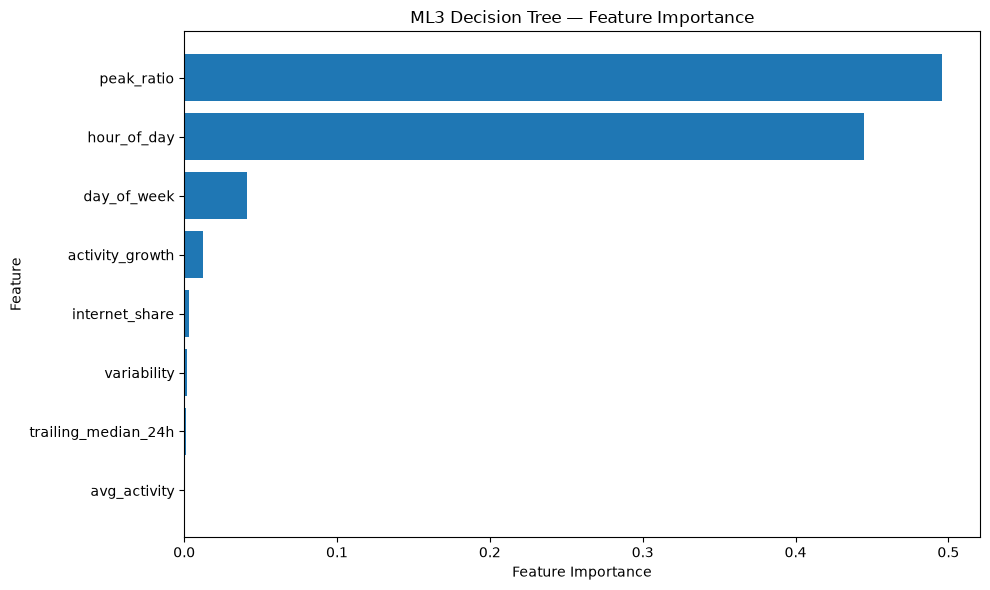

2026-09-07 15:13:37,170 | INFO | Feature importance plot displayed.


In [73]:
# Cell 73 — Plot final Decision Tree feature importance

import matplotlib.pyplot as plt

logging.info("Plotting Decision Tree feature importance...")

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("ML3 Decision Tree — Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

logging.info("Feature importance plot displayed.")

In [74]:
# Cell 70 — Save complete ML3 model metadata

import json
import os

logging.info("Creating complete ML3 model metadata...")

# Convert feature importance DataFrame into JSON-friendly records
feature_importance_records = []

for _, row in feature_importance_df.iterrows():
    feature_importance_records.append({
        "feature": str(row["feature"]),
        "importance": float(row["importance"]),
        "importance_percentage": float(row["importance"] * 100)
    })

# Calculate combined importance of the two dominant features
top_two_importance = float(
    feature_importance_df.head(2)["importance"].sum()
)

ML3_METADATA = {
    "project": "Telecom Network Operations & Predictive Intelligence",

    "model_name": "ML3 High Activity Risk Decision Tree",

    "model_purpose": (
        "Predict whether the next hourly interval for a grid "
        "will experience unusually high telecom activity."
    ),

    "prediction_unit": "one grid + one hourly interval",

    "prediction_horizon": "next_hour",

    "target_column": TARGET_COLUMN,

    "target_definition": (
        "high_activity = 1 when target_activity > "
        "1.5 * trailing_median_24h"
    ),

    "target_threshold_multiplier": 1.5,

    "target_interpretation": (
        "Synthetic training proxy for unusually high activity; "
        "not a confirmed network congestion threshold."
    ),

    "business_action": "investigate",

    "operational_interpretation": (
        "A positive prediction indicates high-activity risk "
        "and should be investigated. It does not confirm "
        "network congestion."
    ),

    "primary_model": {
        "algorithm": "DecisionTreeClassifier",
        "selection_reason": (
            "Selected as primary model because it outperformed "
            "the Logistic Regression benchmark on the chronological "
            "hold-out test set across accuracy, precision, recall, "
            "F1, ROC-AUC and PR-AUC."
        ),
        "parameters": {
            "max_depth": BEST_DT_DEPTH,
            "min_samples_leaf": BEST_DT_LEAF,
            "class_weight": "balanced",
            "random_state": 42
        }
    },

    "secondary_model": {
        "algorithm": "LogisticRegression",
        "role": "benchmark",
        "description": (
            "Log-transformed Logistic Regression retained as a "
            "secondary benchmark model."
        )
    },

    "features": ENGINEERED_FEATURES,

    "excluded_features": {
        "active_hours": (
            "Excluded from model input because it had zero variance "
            "and was constant at 24 for retained feature windows."
        ),
        "target_activity": (
            "Excluded because it represents the next-hour target value "
            "and would cause data leakage."
        ),
        "target_timestamp": (
            "Excluded because it identifies the prediction target time "
            "and is not a predictive feature."
        ),
        "high_activity": (
            "Excluded from model inputs because it is the target label."
        )
    },

    "feature_importance": {
        "method": (
            "Decision Tree impurity-based feature importance "
            "(feature_importances_)"
        ),
        "features": feature_importance_records,
        "top_two_combined_importance": top_two_importance,
        "top_two_combined_percentage": top_two_importance * 100,
        "dominant_features": [
            "peak_ratio",
            "hour_of_day"
        ],
        "interpretation": (
            "peak_ratio and hour_of_day were the dominant predictors "
            "used by the Decision Tree. Together they accounted for "
            f"{top_two_importance * 100:.2f}% of total impurity-based "
            "feature importance."
        ),
        "caution": (
            "Feature importance indicates predictive contribution "
            "within the trained tree and does not imply causation."
        )
    },

    "test_metrics": {
        "accuracy": float(final_dt_accuracy),
        "precision": float(final_dt_precision),
        "recall": float(final_dt_recall),
        "f1": float(final_dt_f1),
        "roc_auc": float(final_dt_roc_auc),
        "pr_auc": float(final_dt_ap)
    },

    "logistic_regression_benchmark_metrics": {
        "accuracy": float(log_lr_accuracy),
        "precision": float(log_lr_precision),
        "recall": float(log_lr_recall),
        "f1": float(log_lr_f1),
        "roc_auc": float(log_lr_roc_auc),
        "pr_auc": float(log_lr_ap)
    },

    "model_comparison": {
        "primary_model": "Decision Tree",
        "benchmark_model": "Logistic Regression",
        "primary_selection_metric": "F1",
        "primary_selection_reason": (
            "Decision Tree achieved higher F1 and PR-AUC while "
            "also providing higher precision and recall on the "
            "untouched chronological test set."
        )
    },

    "validation": {
        "split_strategy": "chronological",
        "test_set_untouched_during_tuning": True,
        "leakage_checks_passed": True,
        "threshold_tuning_performed": True,
        "selected_classification_threshold": 0.50
    },

    "data_split": {
        "strategy": "chronological 80/20 split",
        "training_period": (
            f"{train_timestamps_engineered.min()} "
            f"to {train_timestamps_engineered.max()}"
        ),
        "test_period": (
            f"{test_timestamps_engineered.min()} "
            f"to {test_timestamps_engineered.max()}"
        )
    },

    "feature_engineering": {
        "added_features": [
            "trailing_median_24h",
            "hour_of_day",
            "day_of_week"
        ],
        "log_transformed_features": [
            "avg_activity",
            "peak_ratio",
            "variability",
            "trailing_median_24h"
        ],
        "standardized_features": [
            "activity_growth",
            "internet_share"
        ]
    },

    "model_artifact": {
        "path": FINAL_MODEL_PATH,
        "format": "joblib"
    }
}

METADATA_PATH = "models/ml3_model_metadata.json"

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        ML3_METADATA,
        f,
        indent=4
    )

print("Complete ML3 metadata saved successfully.")
print("-" * 60)
print(f"Metadata file : {METADATA_PATH}")
print()
print("Primary model : Decision Tree")
print(f"Test F1       : {final_dt_f1:.6f}")
print(f"Test PR-AUC   : {final_dt_ap:.6f}")
print()
print("Feature importance:")
for record in feature_importance_records:
    print(
        f"  {record['feature']:<25} "
        f"{record['importance_percentage']:.2f}%"
    )

logging.info(
    f"Complete ML3 metadata saved to {METADATA_PATH}"
)

2026-09-07 15:13:37,188 | INFO | Creating complete ML3 model metadata...
2026-09-07 15:13:37,195 | INFO | Complete ML3 metadata saved to models/ml3_model_metadata.json


Complete ML3 metadata saved successfully.
------------------------------------------------------------
Metadata file : models/ml3_model_metadata.json

Primary model : Decision Tree
Test F1       : 0.476555
Test PR-AUC   : 0.366067

Feature importance:
  peak_ratio                49.59%
  hour_of_day               44.48%
  day_of_week               4.10%
  activity_growth           1.20%
  internet_share            0.32%
  variability               0.17%
  trailing_median_24h       0.14%
  avg_activity              0.00%


comparing aganist np3....

In [75]:
# Cell 74 — Load NP3 rule-based activity spike alerts

logging.info("Loading NP3 rule-based ACTIVITY_SPIKE alerts...")

NP3_SPIKE_QUERY = """
SELECT
    grid_id,
    timestamp,
    alert_type,
    severity,
    current_activity,
    baseline_activity,
    reason
FROM activity_alerts
WHERE alert_type = 'ACTIVITY_SPIKE'
ORDER BY timestamp, grid_id
"""

np3_spike_df = pd.read_sql(
    NP3_SPIKE_QUERY,
    engine
)

np3_spike_df["timestamp"] = pd.to_datetime(
    np3_spike_df["timestamp"]
)

print("NP3 ACTIVITY_SPIKE alerts")
print("=" * 60)
print(f"Rows              : {len(np3_spike_df):,}")
print(f"Unique grids      : {np3_spike_df['grid_id'].nunique():,}")
print(
    f"Timestamp range   : "
    f"{np3_spike_df['timestamp'].min()} → "
    f"{np3_spike_df['timestamp'].max()}"
)

print("\nAlert severity:")
print(np3_spike_df["severity"].value_counts())

logging.info(
    f"Loaded {len(np3_spike_df):,} NP3 ACTIVITY_SPIKE alerts."
)

2026-09-07 15:13:37,206 | INFO | Loading NP3 rule-based ACTIVITY_SPIKE alerts...
2026-09-07 15:13:39,202 | INFO | Loaded 61,948 NP3 ACTIVITY_SPIKE alerts.


NP3 ACTIVITY_SPIKE alerts
Rows              : 61,948
Unique grids      : 8,763
Timestamp range   : 2013-11-01 01:00:00 → 2013-11-07 23:00:00

Alert severity:
severity
HIGH    61948
Name: count, dtype: int64


In [76]:
# Cell 75 — Generate final Decision Tree predictions

logging.info("Generating final ML3 predictions...")

ml3_predictions_df = engineered_test_df[
    [
        "grid_id",
        "feature_timestamp",
        "target_timestamp",
        "target_activity",
        TARGET_COLUMN
    ]
].copy()

ml3_predictions_df["ml_prediction_probability"] = (
    final_dt_proba
)

ml3_predictions_df["ml_prediction"] = (
    final_dt_pred
)

# Rename target timestamp for clean comparison
ml3_predictions_df = ml3_predictions_df.rename(
    columns={
        "target_timestamp": "timestamp"
    }
)

print("ML3 prediction output")
print("=" * 60)
print(f"Rows              : {len(ml3_predictions_df):,}")
print(f"Unique grids      : {ml3_predictions_df['grid_id'].nunique():,}")
print(
    f"Timestamp range   : "
    f"{ml3_predictions_df['timestamp'].min()} → "
    f"{ml3_predictions_df['timestamp'].max()}"
)

print("\nML3 prediction distribution:")
print(
    ml3_predictions_df["ml_prediction"]
    .value_counts()
    .sort_index()
)

logging.info(
    f"Generated {len(ml3_predictions_df):,} ML3 predictions."
)

2026-09-07 15:13:39,217 | INFO | Generating final ML3 predictions...
2026-09-07 15:13:39,233 | INFO | Generated 239,976 ML3 predictions.


ML3 prediction output
Rows              : 239,976
Unique grids      : 9,999
Timestamp range   : 2013-11-07 00:00:00 → 2013-11-07 23:00:00

ML3 prediction distribution:
ml_prediction
0    194521
1     45455
Name: count, dtype: int64


In [77]:
# Cell 76 — Compare ML3 predictions against NP3 ACTIVITY_SPIKE alerts

logging.info("Comparing ML3 predictions with NP3 ACTIVITY_SPIKE alerts...")

# Keep only the fields required from NP3
np3_compare = np3_spike_df[
    [
        "grid_id",
        "timestamp",
        "alert_type",
        "severity",
        "current_activity",
        "baseline_activity",
        "reason"
    ]
].copy()

# Mark whether an NP3 spike exists
np3_compare["np3_spike"] = 1

# Merge using the SAME grid and SAME target timestamp
comparison_df = ml3_predictions_df.merge(
    np3_compare,
    on=["grid_id", "timestamp"],
    how="left"
)

comparison_df["np3_spike"] = (
    comparison_df["np3_spike"]
    .fillna(0)
    .astype(int)
)

# Characterize agreement/disagreement
comparison_df["comparison_category"] = np.select(
    [
        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_spike"] == 1),

        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_spike"] == 0),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_spike"] == 1),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_spike"] == 0)
    ],
    [
        "BOTH_AGREE_HIGH_ACTIVITY",
        "ML_ONLY",
        "NP3_ONLY",
        "NEITHER"
    ],
    default="UNKNOWN"
)

print("ML3 vs NP3 comparison")
print("=" * 60)

category_counts = (
    comparison_df["comparison_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="rows")
)

category_counts["percentage"] = (
    category_counts["rows"]
    / len(comparison_df)
    * 100
)

print(category_counts.to_string(index=False))

logging.info("ML3 vs NP3 comparison completed.")

2026-09-07 15:13:39,244 | INFO | Comparing ML3 predictions with NP3 ACTIVITY_SPIKE alerts...
2026-09-07 15:13:39,345 | INFO | ML3 vs NP3 comparison completed.


ML3 vs NP3 comparison
                category   rows  percentage
                 NEITHER 185481   77.291479
                 ML_ONLY  43260   18.026803
                NP3_ONLY   9040    3.767043
BOTH_AGREE_HIGH_ACTIVITY   2195    0.914675


In [78]:
# Cell 77 — ML3 vs NP3 agreement statistics

logging.info("Calculating ML3 vs NP3 agreement statistics...")

both_agree = (
    (comparison_df["ml_prediction"] == 1) &
    (comparison_df["np3_spike"] == 1)
).sum()

ml_only = (
    (comparison_df["ml_prediction"] == 1) &
    (comparison_df["np3_spike"] == 0)
).sum()

np3_only = (
    (comparison_df["ml_prediction"] == 0) &
    (comparison_df["np3_spike"] == 1)
).sum()

neither = (
    (comparison_df["ml_prediction"] == 0) &
    (comparison_df["np3_spike"] == 0)
).sum()

total = len(comparison_df)

agreement_rate = (
    (both_agree + neither) / total
)

print("ML3 vs NP3 agreement statistics")
print("=" * 60)
print(f"Total compared rows : {total:,}")
print(f"Both agree          : {both_agree:,} ({both_agree/total:.2%})")
print(f"ML only             : {ml_only:,} ({ml_only/total:.2%})")
print(f"NP3 only            : {np3_only:,} ({np3_only/total:.2%})")
print(f"Neither             : {neither:,} ({neither/total:.2%})")
print(f"Overall agreement   : {agreement_rate:.2%}")

logging.info(
    f"ML3/NP3 agreement={agreement_rate:.4%}, "
    f"both={both_agree:,}, "
    f"ML-only={ml_only:,}, "
    f"NP3-only={np3_only:,}"
)

2026-09-07 15:13:39,357 | INFO | Calculating ML3 vs NP3 agreement statistics...
2026-09-07 15:13:39,362 | INFO | ML3/NP3 agreement=78.2062%, both=2,195, ML-only=43,260, NP3-only=9,040


ML3 vs NP3 agreement statistics
Total compared rows : 239,976
Both agree          : 2,195 (0.91%)
ML only             : 43,260 (18.03%)
NP3 only            : 9,040 (3.77%)
Neither             : 185,481 (77.29%)
Overall agreement   : 78.21%


In [79]:
# Cell 74 — Inspect NP3 rule-based alert types

logging.info("Inspecting NP3 rule-based alert types...")

NP3_ALERT_QUERY = """
SELECT
    alert_type,
    severity,
    COUNT(*) AS alert_count,
    MIN(timestamp) AS first_timestamp,
    MAX(timestamp) AS last_timestamp
FROM activity_alerts
GROUP BY alert_type, severity
ORDER BY alert_type, severity
"""

np3_alert_summary = pd.read_sql(
    NP3_ALERT_QUERY,
    engine
)

print("NP3 RULE-BASED ALERT SUMMARY")
print("=" * 80)
print(np3_alert_summary.to_string(index=False))

logging.info("NP3 alert type inspection completed.")

2026-09-07 15:13:39,375 | INFO | Inspecting NP3 rule-based alert types...
2026-09-07 15:13:41,196 | INFO | NP3 alert type inspection completed.


NP3 RULE-BASED ALERT SUMMARY
    alert_type severity  alert_count     first_timestamp      last_timestamp
 ACTIVITY_DROP   MEDIUM       277065 2013-11-01 00:00:00 2013-11-07 23:00:00
ACTIVITY_SPIKE     HIGH        61948 2013-11-01 01:00:00 2013-11-07 23:00:00
 HIGH_ACTIVITY     HIGH       126864 2013-11-01 00:00:00 2013-11-07 23:00:00


In [80]:
# Cell 75 — Validate NP3 alert uniqueness

logging.info("Checking NP3 alert uniqueness...")

NP3_DUPLICATE_QUERY = """
SELECT
    grid_id,
    timestamp,
    alert_type,
    COUNT(*) AS duplicate_count
FROM activity_alerts
GROUP BY grid_id, timestamp, alert_type
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
"""

np3_duplicates = pd.read_sql(
    NP3_DUPLICATE_QUERY,
    engine
)

print("NP3 duplicate check")
print("=" * 60)
print(f"Duplicate grid/timestamp/type groups: {len(np3_duplicates):,}")

if len(np3_duplicates) > 0:
    print("\nSample duplicates:")
    print(np3_duplicates.head(10).to_string(index=False))
else:
    print("PASS — No duplicate grid/timestamp/alert_type groups.")

logging.info(
    f"NP3 duplicate groups found: {len(np3_duplicates):,}"
)

2026-09-07 15:13:41,209 | INFO | Checking NP3 alert uniqueness...
2026-09-07 15:13:42,710 | INFO | NP3 duplicate groups found: 0


NP3 duplicate check
Duplicate grid/timestamp/type groups: 0
PASS — No duplicate grid/timestamp/alert_type groups.


In [81]:
# Cell 76 — Load NP3 HIGH_ACTIVITY and ACTIVITY_SPIKE alerts

logging.info(
    "Loading NP3 HIGH_ACTIVITY and ACTIVITY_SPIKE alerts..."
)

NP3_HIGH_SPIKE_QUERY = """
SELECT
    grid_id,
    timestamp,
    alert_type,
    severity,
    current_activity,
    baseline_activity,
    reason
FROM activity_alerts
WHERE alert_type IN ('HIGH_ACTIVITY', 'ACTIVITY_SPIKE')
ORDER BY timestamp, grid_id
"""

np3_high_spike_df = pd.read_sql(
    NP3_HIGH_SPIKE_QUERY,
    engine
)

np3_high_spike_df["timestamp"] = pd.to_datetime(
    np3_high_spike_df["timestamp"]
)

print("NP3 comparison alerts")
print("=" * 60)

print(
    np3_high_spike_df["alert_type"]
    .value_counts()
)

print()
print(
    f"Total rows: {len(np3_high_spike_df):,}"
)

logging.info(
    f"Loaded {len(np3_high_spike_df):,} NP3 "
    "HIGH_ACTIVITY/ACTIVITY_SPIKE alerts."
)

2026-09-07 15:13:42,726 | INFO | Loading NP3 HIGH_ACTIVITY and ACTIVITY_SPIKE alerts...
2026-09-07 15:13:47,092 | INFO | Loaded 188,812 NP3 HIGH_ACTIVITY/ACTIVITY_SPIKE alerts.


NP3 comparison alerts
alert_type
HIGH_ACTIVITY     126864
ACTIVITY_SPIKE     61948
Name: count, dtype: int64

Total rows: 188,812


In [82]:
# Cell 77 — Generate final ML3 predictions for comparison

logging.info("Generating final ML3 predictions...")

ml3_predictions_df = engineered_test_df[
    [
        "grid_id",
        "feature_timestamp",
        "target_timestamp",
        "target_activity",
        TARGET_COLUMN
    ]
].copy()

ml3_predictions_df["ml_prediction_probability"] = final_dt_proba
ml3_predictions_df["ml_prediction"] = final_dt_pred

ml3_predictions_df = ml3_predictions_df.rename(
    columns={
        "target_timestamp": "timestamp"
    }
)

print("ML3 prediction output")
print("=" * 60)
print(f"Rows        : {len(ml3_predictions_df):,}")
print(f"Unique grids: {ml3_predictions_df['grid_id'].nunique():,}")

logging.info(
    f"Generated {len(ml3_predictions_df):,} ML3 predictions."
)

2026-09-07 15:13:47,104 | INFO | Generating final ML3 predictions...
2026-09-07 15:13:47,114 | INFO | Generated 239,976 ML3 predictions.


ML3 prediction output
Rows        : 239,976
Unique grids: 9,999


In [83]:
# Cell 78 — Create separate NP3 HIGH_ACTIVITY and ACTIVITY_SPIKE indicators

logging.info("Creating NP3 alert indicators...")

np3_high_indicator = (
    np3_high_spike_df[
        np3_high_spike_df["alert_type"] == "HIGH_ACTIVITY"
    ][
        ["grid_id", "timestamp"]
    ]
    .drop_duplicates()
    .assign(np3_high_activity=1)
)

np3_spike_indicator = (
    np3_high_spike_df[
        np3_high_spike_df["alert_type"] == "ACTIVITY_SPIKE"
    ][
        ["grid_id", "timestamp"]
    ]
    .drop_duplicates()
    .assign(np3_activity_spike=1)
)

# Merge HIGH_ACTIVITY indicator
comparison_df = ml3_predictions_df.merge(
    np3_high_indicator,
    on=["grid_id", "timestamp"],
    how="left"
)

# Merge ACTIVITY_SPIKE indicator
comparison_df = comparison_df.merge(
    np3_spike_indicator,
    on=["grid_id", "timestamp"],
    how="left"
)

comparison_df["np3_high_activity"] = (
    comparison_df["np3_high_activity"]
    .fillna(0)
    .astype(int)
)

comparison_df["np3_activity_spike"] = (
    comparison_df["np3_activity_spike"]
    .fillna(0)
    .astype(int)
)

print("Comparison dataset created")
print("=" * 60)
print(f"Rows: {len(comparison_df):,}")

print()
print("ML3 predictions:")
print(
    comparison_df["ml_prediction"]
    .value_counts()
    .sort_index()
)

print()
print("NP3 HIGH_ACTIVITY alerts:")
print(
    comparison_df["np3_high_activity"]
    .value_counts()
    .sort_index()
)

print()
print("NP3 ACTIVITY_SPIKE alerts:")
print(
    comparison_df["np3_activity_spike"]
    .value_counts()
    .sort_index()
)

logging.info("NP3 indicators successfully merged with ML3 predictions.")

2026-09-07 15:13:47,148 | INFO | Creating NP3 alert indicators...


Comparison dataset created

2026-09-07 15:13:47,288 | INFO | NP3 indicators successfully merged with ML3 predictions.



Rows: 239,976

ML3 predictions:
ml_prediction
0    194521
1     45455
Name: count, dtype: int64

NP3 HIGH_ACTIVITY alerts:
np3_high_activity
0    218536
1     21440
Name: count, dtype: int64

NP3 ACTIVITY_SPIKE alerts:
np3_activity_spike
0    228741
1     11235
Name: count, dtype: int64


In [84]:
# Cell 79 — ML3 vs NP3 HIGH_ACTIVITY comparison

logging.info(
    "Comparing ML3 against NP3 HIGH_ACTIVITY..."
)

comparison_df["high_activity_comparison"] = np.select(
    [
        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_high_activity"] == 1),

        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_high_activity"] == 0),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_high_activity"] == 1),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_high_activity"] == 0)
    ],
    [
        "BOTH_AGREE_HIGH_ACTIVITY",
        "ML_ONLY",
        "NP3_ONLY",
        "NEITHER"
    ],default="UNKNOWN"
)

high_activity_summary = (
    comparison_df["high_activity_comparison"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="rows")
)

high_activity_summary["percentage"] = (
    high_activity_summary["rows"]
    / len(comparison_df)
    * 100
)

print("ML3 vs NP3 HIGH_ACTIVITY")
print("=" * 70)
print(
    high_activity_summary.to_string(index=False)
)

logging.info(
    "ML3 vs NP3 HIGH_ACTIVITY comparison completed."
)

2026-09-07 15:13:47,302 | INFO | Comparing ML3 against NP3 HIGH_ACTIVITY...
2026-09-07 15:13:47,357 | INFO | ML3 vs NP3 HIGH_ACTIVITY comparison completed.


ML3 vs NP3 HIGH_ACTIVITY
                category   rows  percentage
                 NEITHER 189508   78.969564
                 ML_ONLY  29028   12.096210
BOTH_AGREE_HIGH_ACTIVITY  16427    6.845268
                NP3_ONLY   5013    2.088959


In [85]:
# Cell 80 — ML3 vs NP3 ACTIVITY_SPIKE comparison

logging.info(
    "Comparing ML3 against NP3 ACTIVITY_SPIKE..."
)

comparison_df["spike_comparison"] = np.select(
    [
        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_activity_spike"] == 1),

        (comparison_df["ml_prediction"] == 1) &
        (comparison_df["np3_activity_spike"] == 0),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_activity_spike"] == 1),

        (comparison_df["ml_prediction"] == 0) &
        (comparison_df["np3_activity_spike"] == 0)
    ],
    [
        "BOTH_AGREE_SPIKE",
        "ML_ONLY",
        "NP3_ONLY",
        "NEITHER"
    ],default="UNKNOWN"
)

spike_summary = (
    comparison_df["spike_comparison"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="rows")
)

spike_summary["percentage"] = (
    spike_summary["rows"]
    / len(comparison_df)
    * 100
)

print("ML3 vs NP3 ACTIVITY_SPIKE")
print("=" * 70)
print(
    spike_summary.to_string(index=False)
)

logging.info(
    "ML3 vs NP3 ACTIVITY_SPIKE comparison completed."
)

2026-09-07 15:13:47,370 | INFO | Comparing ML3 against NP3 ACTIVITY_SPIKE...
2026-09-07 15:13:47,420 | INFO | ML3 vs NP3 ACTIVITY_SPIKE comparison completed.


ML3 vs NP3 ACTIVITY_SPIKE
        category   rows  percentage
         NEITHER 185481   77.291479
         ML_ONLY  43260   18.026803
        NP3_ONLY   9040    3.767043
BOTH_AGREE_SPIKE   2195    0.914675


In [86]:
# Cell 74 — Save final engineered ML3 dataset

logging.info("Saving final engineered ML3 dataset...")

os.makedirs("data", exist_ok=True)

FINAL_DATASET_PATH = "data/ml3_final_engineered_dataset.pkl"

engineered_df.to_pickle(
    FINAL_DATASET_PATH
)

print("Final engineered ML3 dataset saved.")
print("-" * 60)
print(f"Path: {FINAL_DATASET_PATH}")
print(f"Rows: {len(engineered_df):,}")
print(f"Columns: {len(engineered_df.columns)}")

print("\nSaved columns:")
for col in engineered_df.columns:
    print(" -", col)

logging.info(
    f"Final engineered ML3 dataset saved to "
    f"{FINAL_DATASET_PATH}"
)

2026-09-07 15:13:47,431 | INFO | Saving final engineered ML3 dataset...
2026-09-07 15:13:47,526 | INFO | Final engineered ML3 dataset saved to data/ml3_final_engineered_dataset.pkl


Final engineered ML3 dataset saved.
------------------------------------------------------------
Path: data/ml3_final_engineered_dataset.pkl
Rows: 1,199,884
Columns: 14

Saved columns:
 - grid_id
 - feature_timestamp
 - target_timestamp
 - target_activity
 - trailing_median_24h
 - avg_activity
 - activity_growth
 - active_hours
 - peak_ratio
 - variability
 - internet_share
 - high_activity
 - hour_of_day
 - day_of_week


In [87]:
# Cell 75 — Verify final engineered ML3 dataset

logging.info("Verifying saved engineered ML3 dataset...")

reloaded_ml3_df = pd.read_pickle(
    FINAL_DATASET_PATH
)

print("Reload verification")
print("=" * 60)
print(f"Rows    : {len(reloaded_ml3_df):,}")
print(f"Columns : {len(reloaded_ml3_df.columns)}")

required_final_features = [
    "avg_activity",
    "activity_growth",
    "peak_ratio",
    "variability",
    "internet_share",
    "trailing_median_24h",
    "hour_of_day",
    "day_of_week"
]

missing_features = [
    f for f in required_final_features
    if f not in reloaded_ml3_df.columns
]

print("\nRequired final features:")
for feature in required_final_features:
    status = "✓" if feature in reloaded_ml3_df.columns else "✗"
    print(f"{status} {feature}")

assert len(missing_features) == 0

print("\nPASS — All final engineered features are present.")

logging.info(
    "Final engineered ML3 dataset successfully verified."
)

2026-09-07 15:13:47,538 | INFO | Verifying saved engineered ML3 dataset...


Reload verification
Rows    : 1,199,884
Columns : 14


2026-09-07 15:13:47,593 | INFO | Final engineered ML3 dataset successfully verified.



Required final features:
✓ avg_activity
✓ activity_growth
✓ peak_ratio
✓ variability
✓ internet_share
✓ trailing_median_24h
✓ hour_of_day
✓ day_of_week

PASS — All final engineered features are present.


In [88]:
# Cell 76 — Save final engineered ML3 dataset as CSV

import os

logging.info("Saving final engineered ML3 dataset as CSV...")

os.makedirs("data", exist_ok=True)

FINAL_CSV_PATH = "data/ml3_final_engineered_dataset.csv"

engineered_df.to_csv(
    FINAL_CSV_PATH,
    index=False
)

print("Final engineered ML3 dataset saved successfully.")
print("-" * 60)
print(f"File path : {FINAL_CSV_PATH}")
print(f"Rows      : {len(engineered_df):,}")
print(f"Columns   : {len(engineered_df.columns):,}")

print("\nColumns saved:")
for col in engineered_df.columns:
    print(f" - {col}")

logging.info(
    f"Final engineered ML3 CSV saved to {FINAL_CSV_PATH} "
    f"with {len(engineered_df):,} rows and "
    f"{len(engineered_df.columns)} columns."
)

2026-09-07 15:13:47,604 | INFO | Saving final engineered ML3 dataset as CSV...
2026-09-07 15:13:56,657 | INFO | Final engineered ML3 CSV saved to data/ml3_final_engineered_dataset.csv with 1,199,884 rows and 14 columns.


Final engineered ML3 dataset saved successfully.
------------------------------------------------------------
File path : data/ml3_final_engineered_dataset.csv
Rows      : 1,199,884
Columns   : 14

Columns saved:
 - grid_id
 - feature_timestamp
 - target_timestamp
 - target_activity
 - trailing_median_24h
 - avg_activity
 - activity_growth
 - active_hours
 - peak_ratio
 - variability
 - internet_share
 - high_activity
 - hour_of_day
 - day_of_week


In [89]:
# ============================================================
# ML3 — VERIFY TIMESTAMP FORMAT BEFORE RESAVING
# ============================================================

import os
import pandas as pd

print("Checking ML3 engineered dataset before resaving...")

print(f"Rows       : {len(engineered_df):,}")
print(f"Columns    : {len(engineered_df.columns)}")
print(f"Timestamp dtype: {engineered_df['feature_timestamp'].dtype}")

print("\nTimestamp range:")
print(f"Min: {engineered_df['feature_timestamp'].min()}")
print(f"Max: {engineered_df['feature_timestamp'].max()}")

print("\nFirst 10 timestamps:")
print(
    engineered_df["feature_timestamp"]
    .head(10)
    .to_string(index=False)
)

# Explicitly convert to datetime in memory
engineered_df["feature_timestamp"] = pd.to_datetime(
    engineered_df["feature_timestamp"],
    errors="raise"
)

print("\nAfter explicit conversion:")
print(f"Timestamp dtype: {engineered_df['feature_timestamp'].dtype}")

print("\nValidation passed — no invalid timestamps.")

Checking ML3 engineered dataset before resaving...
Rows       : 1,199,884
Columns    : 14
Timestamp dtype: datetime64[us]

Timestamp range:
Min: 2013-11-02 23:00:00
Max: 2013-11-07 22:00:00

First 10 timestamps:
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00
2013-11-02 23:00:00

After explicit conversion:
Timestamp dtype: datetime64[us]

Validation passed — no invalid timestamps.


In [90]:
# ============================================================
# ML3 — RESAVE FINAL ENGINEERED DATASET
# ============================================================

import os

ML3_FINAL_PATH = "data/ml3_final_engineered_dataset.csv"

print("Resaving ML3 engineered dataset with explicit timestamp format...")

# Ensure directory exists
os.makedirs("data", exist_ok=True)

# Save with explicit datetime formatting
engineered_df.to_csv(
    ML3_FINAL_PATH,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

print("\nML3 dataset successfully resaved.")
print(f"Path: {ML3_FINAL_PATH}")
print(f"Rows: {len(engineered_df):,}")
print(f"Size: {os.path.getsize(ML3_FINAL_PATH) / (1024**2):.2f} MB")

Resaving ML3 engineered dataset with explicit timestamp format...

ML3 dataset successfully resaved.
Path: data/ml3_final_engineered_dataset.csv
Rows: 1,199,884
Size: 200.51 MB


In [99]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 22.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 10.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [102]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 2.9/100.2 MB 21.0 MB/s eta 0:00:05
   --- ------------------------------------ 8.1/100.2 MB 25.1 MB/s eta 0:00:04
   ----- ---------------------------------- 14.2/100.2 MB 25.4 MB/s eta 0:00:04
   -------- ------------------------------- 21.0/100.2 MB 28.8 MB/s eta 0:00:03
   ----------- ---------------------------- 27.8/100.2 MB 28.4 MB/s eta 0:00:03
   -------------- ------------------------- 35.9/100.2 MB 30.4 MB/s eta 0:00:03
   ----------------- ---------------------- 43.5/100.2 MB 31.1 MB/s eta 0:00:02
   -------------------- ------------------- 51.6/100.2 MB 31.9 MB/s eta 0:00:02
   ------------------------ --------------- 60.6/100.2 MB 33.6 MB/s eta 0:00:02
   -------------------------- ------------- 65.8/100.2 MB 32.5 MB/s eta 0:00:02
   --------------------------- ------------ 70.0/100.2 MB 31.9 MB/s eta 0:00:01
   ----------------------------- ---------- 74.4/10

In [116]:
# Cell 66 — Train final Decision Tree on the complete training period

# logging.info("Training final Decision Tree on complete training data...")
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
num_neg = (y_train_eng == 0).sum()
num_pos = (y_train_eng == 1).sum()

scale_pos_weight = num_neg / num_pos

final_dt_model =  LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)



final_dt_model.fit(X_train_eng, y_train_eng)

# logging.info(
#     f"Final Decision Tree trained with "
#     f"max_depth={BEST_DT_DEPTH}, "
#     f"min_samples_leaf={BEST_DT_LEAF}"
# )

# print("Final Decision Tree trained successfully.")
# print(f"max_depth        : {BEST_DT_DEPTH}")
# print(f"min_samples_leaf : {BEST_DT_LEAF}")

[LightGBM] [Info] Number of positive: 100405, number of negative: 859503
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1559
[LightGBM] [Info] Number of data points in the train set: 959908, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.104599 -> initscore=-2.147142
[LightGBM] [Info] Start training from score -2.147142


,max_depth,6
,learning_rate,0.05
,n_estimators,500
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [121]:
# Cell 67 — Final Decision Tree evaluation on untouched test set

# logging.info("Evaluating final Decision Tree on untouched test set...")

final_dt_proba = final_dt_model.predict_proba(
    X_test_eng
)[:, 1]

final_dt_pred = (
    final_dt_proba >= 0.3
).astype(int)

final_dt_accuracy = accuracy_score(
    y_test_eng,
    final_dt_pred
)

final_dt_precision = precision_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_recall = recall_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_f1 = f1_score(
    y_test_eng,
    final_dt_pred,
    zero_division=0
)

final_dt_roc_auc = roc_auc_score(
    y_test_eng,
    final_dt_proba
)

final_dt_ap = average_precision_score(
    y_test_eng,
    final_dt_proba
)

print("FINAL DECISION TREE — TEST RESULTS")
print("=" * 60)
print(f"Accuracy  : {final_dt_accuracy:.6f}")
print(f"Precision : {final_dt_precision:.6f}")
print(f"Recall    : {final_dt_recall:.6f}")
print(f"F1 Score  : {final_dt_f1:.6f}")
print(f"ROC-AUC   : {final_dt_roc_auc:.6f}")
print(f"PR-AUC/AP : {final_dt_ap:.6f}")

# logging.info(
#     f"Final DT test results: "
#     f"accuracy={final_dt_accuracy:.6f}, "
#     f"precision={final_dt_precision:.6f}, "
#     f"recall={final_dt_recall:.6f}, "
#     f"f1={final_dt_f1:.6f}, "
#     f"roc_auc={final_dt_roc_auc:.6f}, "
#     f"ap={final_dt_ap:.6f}"
# )

FINAL DECISION TREE — TEST RESULTS
Accuracy  : 0.939552
Precision : 0.622276
Recall    : 0.641716
F1 Score  : 0.631846
ROC-AUC   : 0.942414
PR-AUC/AP : 0.695122
